# 18 — Cluster Profiling: All 5 Images + Clinical (corrected M/F encoding)

Same RelMS setup as notebook 09 (5 image blocks + clinical) with one correction:

| Block | Features | Size | Distance | Change vs nb09 |
|-------|----------|------|----------|----------------|
| Image blocks 1–5 | 110 PCA per type | 5×110 | euclidean | — |
| Clinical quant (p1 block 6) | Age, MMSE, eTIV, nWBV, ASF | 5 | euclidean | — |
| Binary (p2) | *(none)* | **0** | sokal | **M/F removed from here** |
| Multiclass (p3) | **M/F**, Educ, SES | **3** | hamming | **M/F added here** |

**Why M/F moves to multiclass**: M/F is a nominal categorical variable (two named
categories: Male / Female). The `sokal` distance was designed for asymmetric
presence/absence binary data, not for nominal labels. `hamming` is the correct
distance for any nominal categorical variable including binary ones.

**Main goal**: profile each cluster by the distribution of every clinical feature,
and visualise how separated the clusters are in 2D (MDS embedding of distance matrix).

## 0 — Install & imports

In [2]:
import subprocess, sys

def run_pip(*args):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + list(args),
                       capture_output=True, text=True)
    print(f"  {'OK' if r.returncode == 0 else 'FAIL'}  {args[-1]}")

run_pip('robust-mixed-dist==0.1.26')
for pkg in ['kmedoids', 'seaborn', 'openpyxl']:
    run_pip(pkg)
print('Done.')

  OK  robust-mixed-dist==0.1.26
  OK  kmedoids
  OK  seaborn
  OK  openpyxl
Done.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import kmedoids
from robust_mixed_dist.mixed import related_metric_scaling_dist_matrix_faster
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

sns.set_theme(style='whitegrid', font_scale=1.1)

NB_FOLDER = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_FOLDER, '..', '..'))
DATA_PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'notebooks', '01_data_pipeline')
OUTPUT_DIR = NB_FOLDER
NB_DIR = DATA_PIPELINE_DIR      # legacy alias: shared pipeline inputs (pca_*.csv, clinical xlsx)
NB_PADDED = OUTPUT_DIR          # legacy alias: this notebook's own outputs

print('All imports OK.')

All imports OK.


## 1 — Load and filter clinical data

Drop patients missing **Educ, SES or MMSE** (same as nb09). CDR kept only for
post-hoc evaluation.

In [5]:
df_clin = pd.read_excel(
    os.path.join(NB_DIR, 'oasis_cross-sectional-5708aa0a98d82080.xlsx')
)
if 'ID' in df_clin.columns:
    df_clin = df_clin.rename(columns={'ID': 'patient_id'})

df_clin['patient_id'] = df_clin['patient_id'].str.replace(r'_MR\d+$', '', regex=True)
df_clin = (
    df_clin
    .sort_values('CDR', na_position='last')
    .drop_duplicates(subset='patient_id', keep='first')
    .reset_index(drop=True)
)

FEATURE_COLS = ['Age', 'M/F', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
KEEP         = ['patient_id'] + FEATURE_COLS + ['CDR']
df_clin      = df_clin[KEEP].copy()
df_clin      = df_clin.dropna(subset=['Educ', 'SES', 'MMSE']).reset_index(drop=True)

print(f'Patients (complete cases): {len(df_clin)}')
print(f'All have CDR: {df_clin["CDR"].notnull().all()}')
print('\nCDR counts:')
print(df_clin['CDR'].value_counts().sort_index())
print('\nEduc unique:', sorted(df_clin['Educ'].unique()))
print('SES unique :', sorted(df_clin['SES'].unique()))
print('M/F unique :', sorted(df_clin['M/F'].unique()))

Patients (complete cases): 216
All have CDR: True

CDR counts:
CDR
0.0    133
0.5     57
1.0     24
2.0      2
Name: count, dtype: int64

Educ unique: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
SES unique : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
M/F unique : ['F', 'M']


## 2 — Load and align PCA blocks

In [6]:
PCA_FILES = [
    ('cor',        'pca_cor.csv'),
    ('gfc_sag',    'pca_gfc_sag.csv'),
    ('gfc_tra',    'pca_gfc_tra.csv'),
    ('masked_tra', 'pca_masked_tra.csv'),
    ('sbj_sag',    'pca_sbj_sag.csv'),
]

pca_blocks = {}
for itype, fname in PCA_FILES:
    df = pd.read_csv(os.path.join(NB_DIR, fname))
    df_aligned = df_clin[['patient_id']].merge(df, on='patient_id', how='left')
    pca_cols   = [c for c in df_aligned.columns if c != 'patient_id']
    pca_blocks[itype] = df_aligned[pca_cols].to_numpy(dtype=np.float64)
    print(f'  {itype:<14} shape: {pca_blocks[itype].shape}  '
          f'NaN: {np.isnan(pca_blocks[itype]).sum()}')

  cor            shape: (216, 110)  NaN: 0
  gfc_sag        shape: (216, 110)  NaN: 0
  gfc_tra        shape: (216, 110)  NaN: 0
  masked_tra     shape: (216, 110)  NaN: 0
  sbj_sag        shape: (216, 110)  NaN: 0


## 3 — Build feature matrix X

Column layout (p1 first, p3 last — required by RelMS):
```
[cor×110] [gfc_sag×110] [gfc_tra×110] [masked_tra×110] [sbj_sag×110]
[Age MMSE eTIV nWBV ASF ×5]   [MF Educ SES ×3]
```
Total: 558 columns (5×110 + 5 + 3).

**Key change vs nb09**: `M/F` moved from p2 (binary/sokal) into p3 (multiclass/hamming)
alongside Educ and SES. `p2=0` — no binary block.

In [7]:
df_c = df_clin.copy()
df_c['MF']   = (df_c['M/F'] == 'M').astype(np.float64)   # 0=F, 1=M (for hamming in p3)
df_c['Educ'] = df_c['Educ'].astype(np.float64)
df_c['SES']  = df_c['SES'].astype(np.float64)

QUANT_CLIN   = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF']   # 5 quantitative → p1
MULTCLS_CLIN = ['MF', 'Educ', 'SES']                      # 3 nominal/ordinal → p3

X = np.concatenate([
    pca_blocks['cor'],                                        # 110 ─┐
    pca_blocks['gfc_sag'],                                    # 110  │ p1
    pca_blocks['gfc_tra'],                                    # 110  │
    pca_blocks['masked_tra'],                                 # 110  │
    pca_blocks['sbj_sag'],                                    # 110  │
    df_c[QUANT_CLIN].to_numpy(dtype=np.float64),              #   5 ─┘
    df_c[MULTCLS_CLIN].to_numpy(dtype=np.float64),            #   3 ── p3
], axis=1)

patient_ids = df_c['patient_id'].values

print(f'X shape : {X.shape}  (expected ({len(df_clin)}, 558))')
print(f'NaN in X: {np.isnan(X).sum()}')
assert X.shape[1] == 558, f'Shape mismatch: {X.shape[1]}'

X shape : (216, 558)  (expected (216, 558))
NaN in X: 0


## 4 — Compute RelMS distance matrix

`p1=[110,110,110,110,110,5]` — five image blocks + quantitative clinical block,
each normalised by its own geometric variability before combining.
`p2=0` — no binary block.
`p3=3` — M/F, Educ, SES as multiclass (hamming).

In [8]:
print('Computing RelMS distance matrix ...')

D = related_metric_scaling_dist_matrix_faster(
    X=pd.DataFrame(X),
    p1=[110, 110, 110, 110, 110, 5],   # 5 image blocks + 5 quant clinical
    p2=0,                               # no binary block
    p3=3,                               # M/F, Educ, SES — multiclass / hamming
    d1='euclidean',
    d2='sokal',
    d3='hamming',
    weights=None,
)

print(f'D shape      : {D.shape}')
print(f'Value range  : [{D.min():.4f}, {D.max():.4f}]')
print(f'NaN in D     : {np.isnan(D).sum()}')
print(f'Symmetric    : {np.allclose(D, D.T)}')

Computing RelMS distance matrix ...
D shape      : (216, 216)
Value range  : [0.0000, 9.0430]
NaN in D     : 0
Symmetric    : True


C:\Users\aregk\AppData\Local\Programs\Python\Python312\Lib\site-packages\robust_mixed_dist\mixed.py:1002: UserWarning: Gram matrix for block 8 is not PSD (min eig=-1.76e+01). Transformation applied.
  warnings.warn(


## 5 — Cluster k=3 and k=4

In [9]:
cluster_labels = {}

for k in [2, 3]:
    result = kmedoids.fasterpam(D, medoids=k, random_state=42)
    cluster_labels[k] = np.array(result.labels, dtype=int)
    sizes = {c: int((cluster_labels[k] == c).sum()) for c in sorted(set(cluster_labels[k]))}
    print(f'k={k}  loss={result.loss:.4f}  sizes={sizes}')

k=2  loss=1569.3695  sizes={np.int64(0): 146, np.int64(1): 70}
k=3  loss=1556.9004  sizes={np.int64(0): 65, np.int64(1): 56, np.int64(2): 95}


## 6 — Standard evaluation (ARI, NMI, silhouette, spread)

In [10]:
cdr_values = df_c['CDR'].values
cdr_int    = (cdr_values * 2).astype(int)

eval_results = []

for k in [2, 3]:
    labels = cluster_labels[k]
    sil    = silhouette_score(D, labels, metric='precomputed')
    ari    = adjusted_rand_score(cdr_int, labels)
    nmi    = normalized_mutual_info_score(cdr_int, labels)

    df_ev   = pd.DataFrame({'cluster': labels, 'CDR': cdr_values})
    pct_tab = pd.crosstab(df_ev['cluster'], df_ev['CDR'], normalize='index').mul(100)
    spread  = float(pct_tab.get(0.0, pd.Series(0.0, index=pct_tab.index)).pipe(
                   lambda s: s.max() - s.min()))

    print(f'k={k}: sil={sil:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}  spread={spread:.2f}%')
    eval_results.append({'k': k, 'silhouette': round(sil, 4),
                         'ari': round(ari, 4), 'nmi': round(nmi, 4),
                         'spread_pct_healthy': round(spread, 2)})

df_eval = pd.DataFrame(eval_results)
print()
print(df_eval.to_string(index=False))

k=2: sil=0.0262  ARI=0.0283  NMI=0.0107  spread=10.78%
k=3: sil=0.0091  ARI=0.0176  NMI=0.0188  spread=10.45%

 k  silhouette    ari    nmi  spread_pct_healthy
 2      0.0262 0.0283 0.0107               10.78
 3      0.0091 0.0176 0.0188               10.45


## 7 — Cluster profiling: summary statistics

For each k, show the mean ± std of every quantitative clinical feature within each cluster,
and the proportion breakdown of CDR, M/F, Educ, SES.

In [11]:
QUANT_DISPLAY = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'Educ', 'SES']
CAT_DISPLAY   = ['CDR', 'M/F']

for k in [2, 3]:
    print(f'\n{"="*70}')
    print(f'  CLUSTER PROFILING — k={k}')
    print(f'{"="*70}')

    labels     = cluster_labels[k]
    df_profile = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    # ── Cluster sizes ─────────────────────────────────────────────────────────
    sizes = df_profile['cluster'].value_counts().sort_index()
    print('\nCluster sizes:')
    for c, n in sizes.items():
        print(f'  Cluster {c}: n={n}')

    # ── Quantitative features — mean ± std ────────────────────────────────────
    print('\nQuantitative features (mean ± std):')
    header = 'Feature      ' + '  '.join(f'  Cluster {c}   ' for c in cluster_ids)
    print(header)
    print('-' * len(header))
    for feat in QUANT_DISPLAY:
        parts = []
        for c in cluster_ids:
            vals = df_profile.loc[df_profile['cluster'] == c, feat]
            parts.append(f'{vals.mean():6.2f} ± {vals.std():5.2f}')
        print(f'{feat:<12} ' + '  '.join(parts))

    # ── CDR distribution ──────────────────────────────────────────────────────
    print('\nCDR distribution per cluster (count and row %):')
    ct  = pd.crosstab(df_profile['cluster'], df_profile['CDR'],
                      margins=True, margins_name='Total')
    pct = pd.crosstab(df_profile['cluster'], df_profile['CDR'],
                      normalize='index').mul(100).round(1)
    print('Counts:')
    print(ct.to_string())
    print('Row %:')
    print(pct.to_string())

    # ── M/F ───────────────────────────────────────────────────────────────────
    print('\nM/F distribution (% female):')
    mf_pct = df_profile.groupby('cluster')['M/F'].value_counts(normalize=True).mul(100).round(1)
    print(mf_pct.to_string())

    # ── Educ ─────────────────────────────────────────────────────────────────
    print('\nEduc distribution per cluster (%):')
    educ_pct = pd.crosstab(df_profile['cluster'], df_profile['Educ'],
                           normalize='index').mul(100).round(1)
    print(educ_pct.to_string())

    # ── SES ──────────────────────────────────────────────────────────────────
    print('\nSES distribution per cluster (%):')
    ses_pct = pd.crosstab(df_profile['cluster'], df_profile['SES'],
                          normalize='index').mul(100).round(1)
    print(ses_pct.to_string())


  CLUSTER PROFILING — k=2

Cluster sizes:
  Cluster 0: n=146
  Cluster 1: n=70

Quantitative features (mean ± std):
Feature        Cluster 0       Cluster 1   
-------------------------------------------
Age           72.63 ± 11.60   72.06 ± 13.75
MMSE          27.38 ±  3.45   27.21 ±  3.42
eTIV         1374.91 ± 93.12  1633.27 ± 127.66
nWBV           0.76 ±  0.05    0.74 ±  0.05
ASF            1.28 ±  0.09    1.08 ±  0.08
Educ           2.95 ±  1.22    3.81 ±  1.38
SES            2.69 ±  1.03    2.07 ±  1.20

CDR distribution per cluster (count and row %):
Counts:
CDR      0.0  0.5  1.0  2.0  Total
cluster                           
0         95   33   17    1    146
1         38   24    7    1     70
Total    133   57   24    2    216
Row %:
CDR       0.0   0.5   1.0  2.0
cluster                       
0        65.1  22.6  11.6  0.7
1        54.3  34.3  10.0  1.4

M/F distribution (% female):
cluster  M/F
0        F      88.4
         M      11.6
1        M      77.1
         F     

## 8 — Visualisations

One figure per k value, each with multiple panels:
- **Top row**: CDR distribution (stacked bar) and cluster sizes (bar)
- **Middle rows**: box plots for quantitative features
- **Bottom row**: M/F, Educ, SES proportions

In [12]:
CDR_COLORS  = {0.0: '#4CAF50', 0.5: '#FFC107', 1.0: '#FF5722', 2.0: '#9C27B0'}
CDR_LABELS  = {0.0: 'CDR 0 (healthy)', 0.5: 'CDR 0.5 (very mild)',
               1.0: 'CDR 1 (mild)',     2.0: 'CDR 2 (moderate)'}
CLUSTER_COLORS = ['#2196F3', '#FF9800', '#E91E63', '#009688']  # up to k=4

def plot_cdr_stacked(ax, df_profile, cluster_ids):
    cdr_order = [0.0, 0.5, 1.0, 2.0]
    ct = pd.crosstab(df_profile['cluster'], df_profile['CDR'], normalize='index') * 100
    bottoms = np.zeros(len(cluster_ids))
    for cdr in cdr_order:
        if cdr not in ct.columns:
            continue
        vals = [ct.loc[c, cdr] if c in ct.index else 0.0 for c in cluster_ids]
        ax.bar(range(len(cluster_ids)), vals, bottom=bottoms,
               color=CDR_COLORS[cdr], label=CDR_LABELS[cdr])
        bottoms += np.array(vals)
    ax.set_xticks(range(len(cluster_ids)))
    ax.set_xticklabels([f'Cluster {c}' for c in cluster_ids])
    ax.set_ylabel('% of patients')
    ax.set_title('CDR distribution per cluster')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 110)

def plot_cluster_sizes(ax, df_profile, cluster_ids):
    sizes = [int((df_profile['cluster'] == c).sum()) for c in cluster_ids]
    bars  = ax.bar(range(len(cluster_ids)), sizes,
                   color=[CLUSTER_COLORS[i] for i in range(len(cluster_ids))])
    for bar, sz in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(sz),
                ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(cluster_ids)))
    ax.set_xticklabels([f'Cluster {c}' for c in cluster_ids])
    ax.set_ylabel('n patients')
    ax.set_title('Cluster sizes')

def plot_boxplots(ax, df_profile, feature, cluster_ids):
    data  = [df_profile.loc[df_profile['cluster'] == c, feature].values for c in cluster_ids]
    bp    = ax.boxplot(data, patch_artist=True, notch=False,
                       medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], CLUSTER_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([f'C{c}' for c in cluster_ids])
    ax.set_title(feature)
    ax.set_ylabel(feature)

def plot_categorical_bars(ax, df_profile, feature, cluster_ids, title=None):
    pct = pd.crosstab(df_profile['cluster'], df_profile[feature], normalize='index') * 100
    categories = sorted(pct.columns)
    x     = np.arange(len(cluster_ids))
    width = 0.8 / len(categories)
    palette = sns.color_palette('Set2', len(categories))
    for i, cat in enumerate(categories):
        vals = [pct.loc[c, cat] if c in pct.index and cat in pct.columns else 0.0
                for c in cluster_ids]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=str(cat), color=palette[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'C{c}' for c in cluster_ids])
    ax.set_ylabel('% within cluster')
    ax.set_title(title or feature)
    ax.legend(title=feature, fontsize=7, loc='upper right')

print('Helper functions defined.')

Helper functions defined.


C:\Users\aregk\AppData\Local\Temp\ipykernel_31380\3262983300.py:36: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


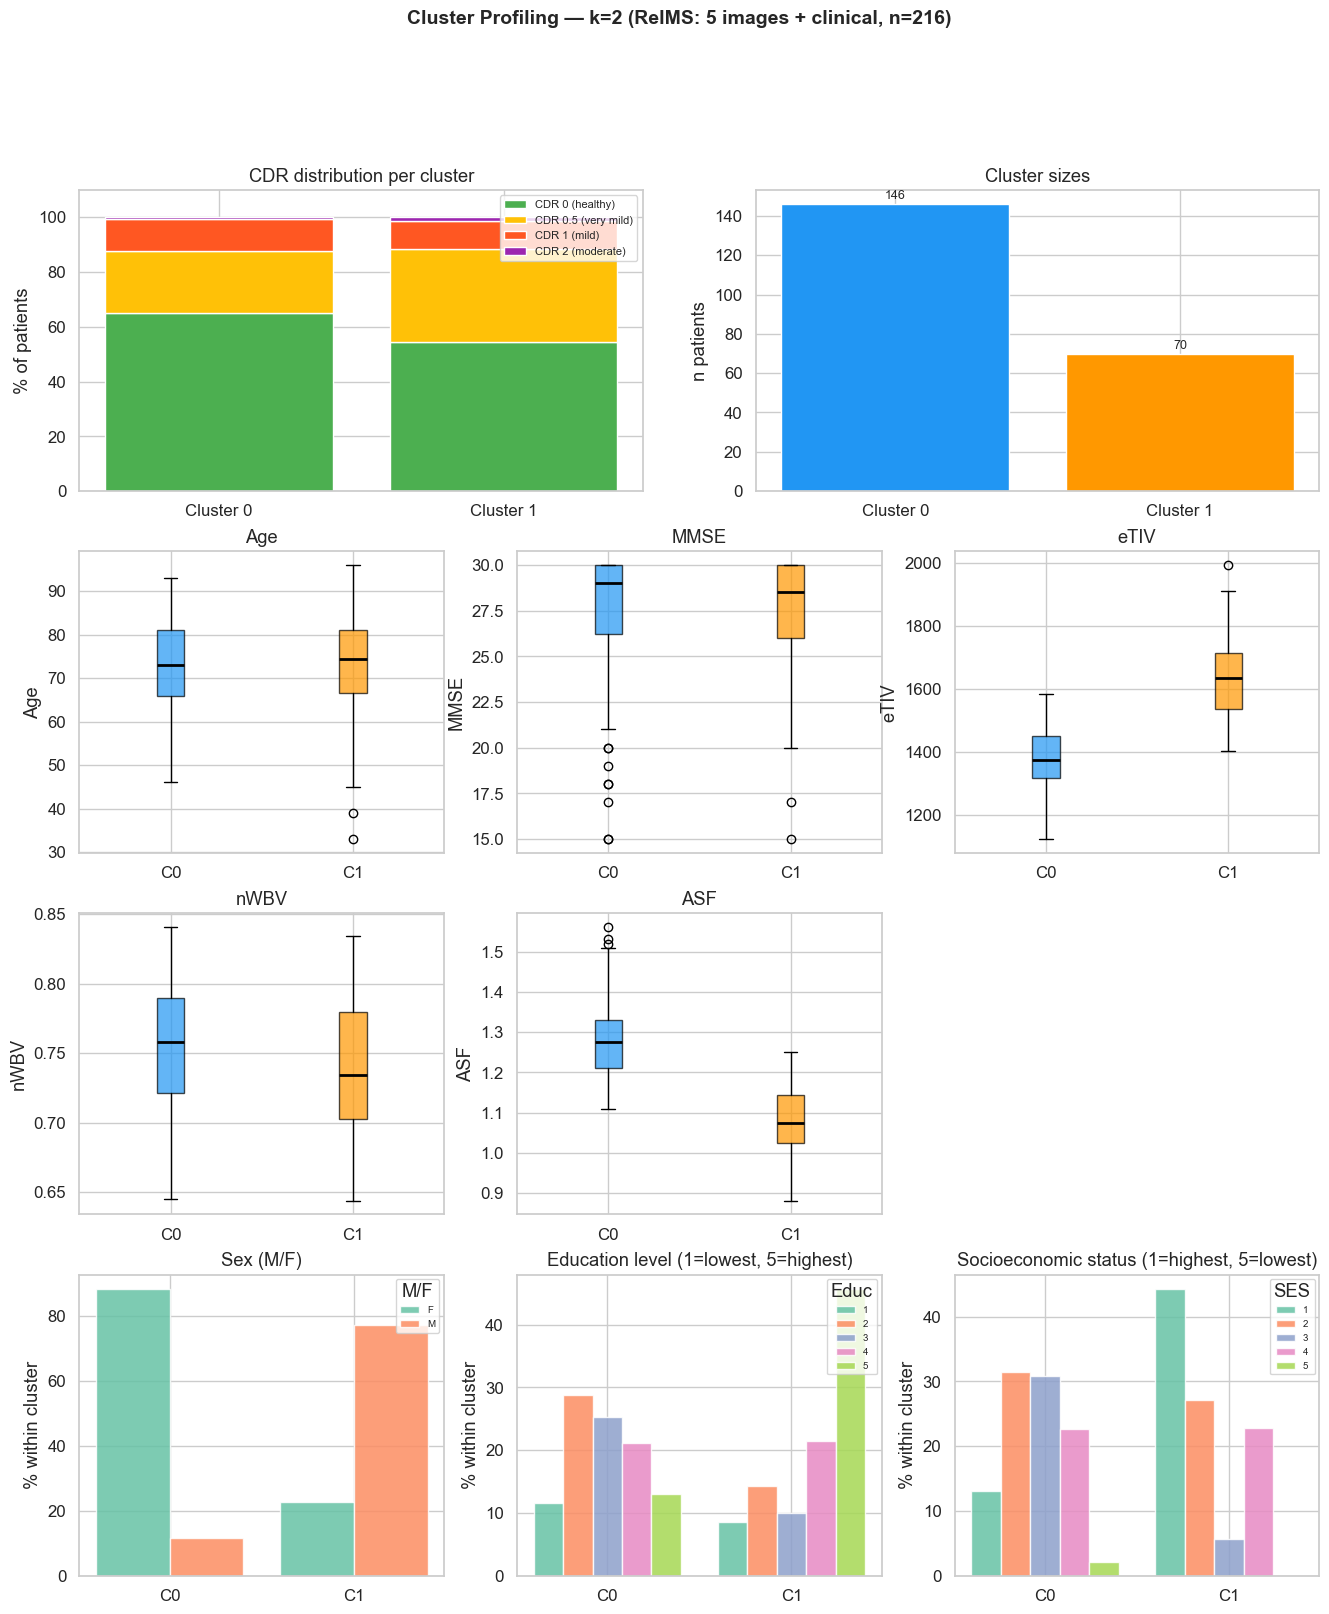

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\cluster_profile_k2.png


In [13]:
# ── k=2 figure ───────────────────────────────────────────────────────────────
k = 2
labels      = cluster_labels[k]
df_profile  = df_c.assign(cluster=labels)
cluster_ids = sorted(df_profile['cluster'].unique())
fig = plt.figure(figsize=(16, 18))
fig.suptitle(f'Cluster Profiling — k={k} (RelMS: 5 images + clinical, n=216)',
             fontsize=14, fontweight='bold', y=0.98)
# Row 1: CDR stacked bar + sizes
ax1 = fig.add_subplot(4, 2, 1)
plot_cdr_stacked(ax1, df_profile, cluster_ids)
ax2 = fig.add_subplot(4, 2, 2)
plot_cluster_sizes(ax2, df_profile, cluster_ids)
# Row 2: Age, MMSE, eTIV
for col_i, feat in enumerate(['Age', 'MMSE', 'eTIV'], start=1):
    ax = fig.add_subplot(4, 3, 3 + col_i)
    plot_boxplots(ax, df_profile, feat, cluster_ids)
# Row 3: nWBV, ASF, (empty)
ax7 = fig.add_subplot(4, 3, 7)
plot_boxplots(ax7, df_profile, 'nWBV', cluster_ids)
ax8 = fig.add_subplot(4, 3, 8)
plot_boxplots(ax8, df_profile, 'ASF', cluster_ids)
ax9 = fig.add_subplot(4, 3, 9)
ax9.axis('off')  # placeholder
# Row 4: M/F, Educ, SES
ax10 = fig.add_subplot(4, 3, 10)
plot_categorical_bars(ax10, df_profile, 'M/F', cluster_ids, title='Sex (M/F)')
ax11 = fig.add_subplot(4, 3, 11)
plot_categorical_bars(ax11, df_profile.assign(Educ=df_c['Educ'].astype(int)),
                      'Educ', cluster_ids,
                      title='Education level (1=lowest, 5=highest)')
ax12 = fig.add_subplot(4, 3, 12)
plot_categorical_bars(ax12, df_profile.assign(SES=df_c['SES'].astype(int)),
                      'SES', cluster_ids,
                      title='Socioeconomic status (1=highest, 5=lowest)')
plt.tight_layout(rect=[0, 0, 1, 0.97])
out_k2 = os.path.join(NB_PADDED, 'cluster_profile_k2.png')
plt.savefig(out_k2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_k2}')

C:\Users\aregk\AppData\Local\Temp\ipykernel_23520\1647536683.py:45: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


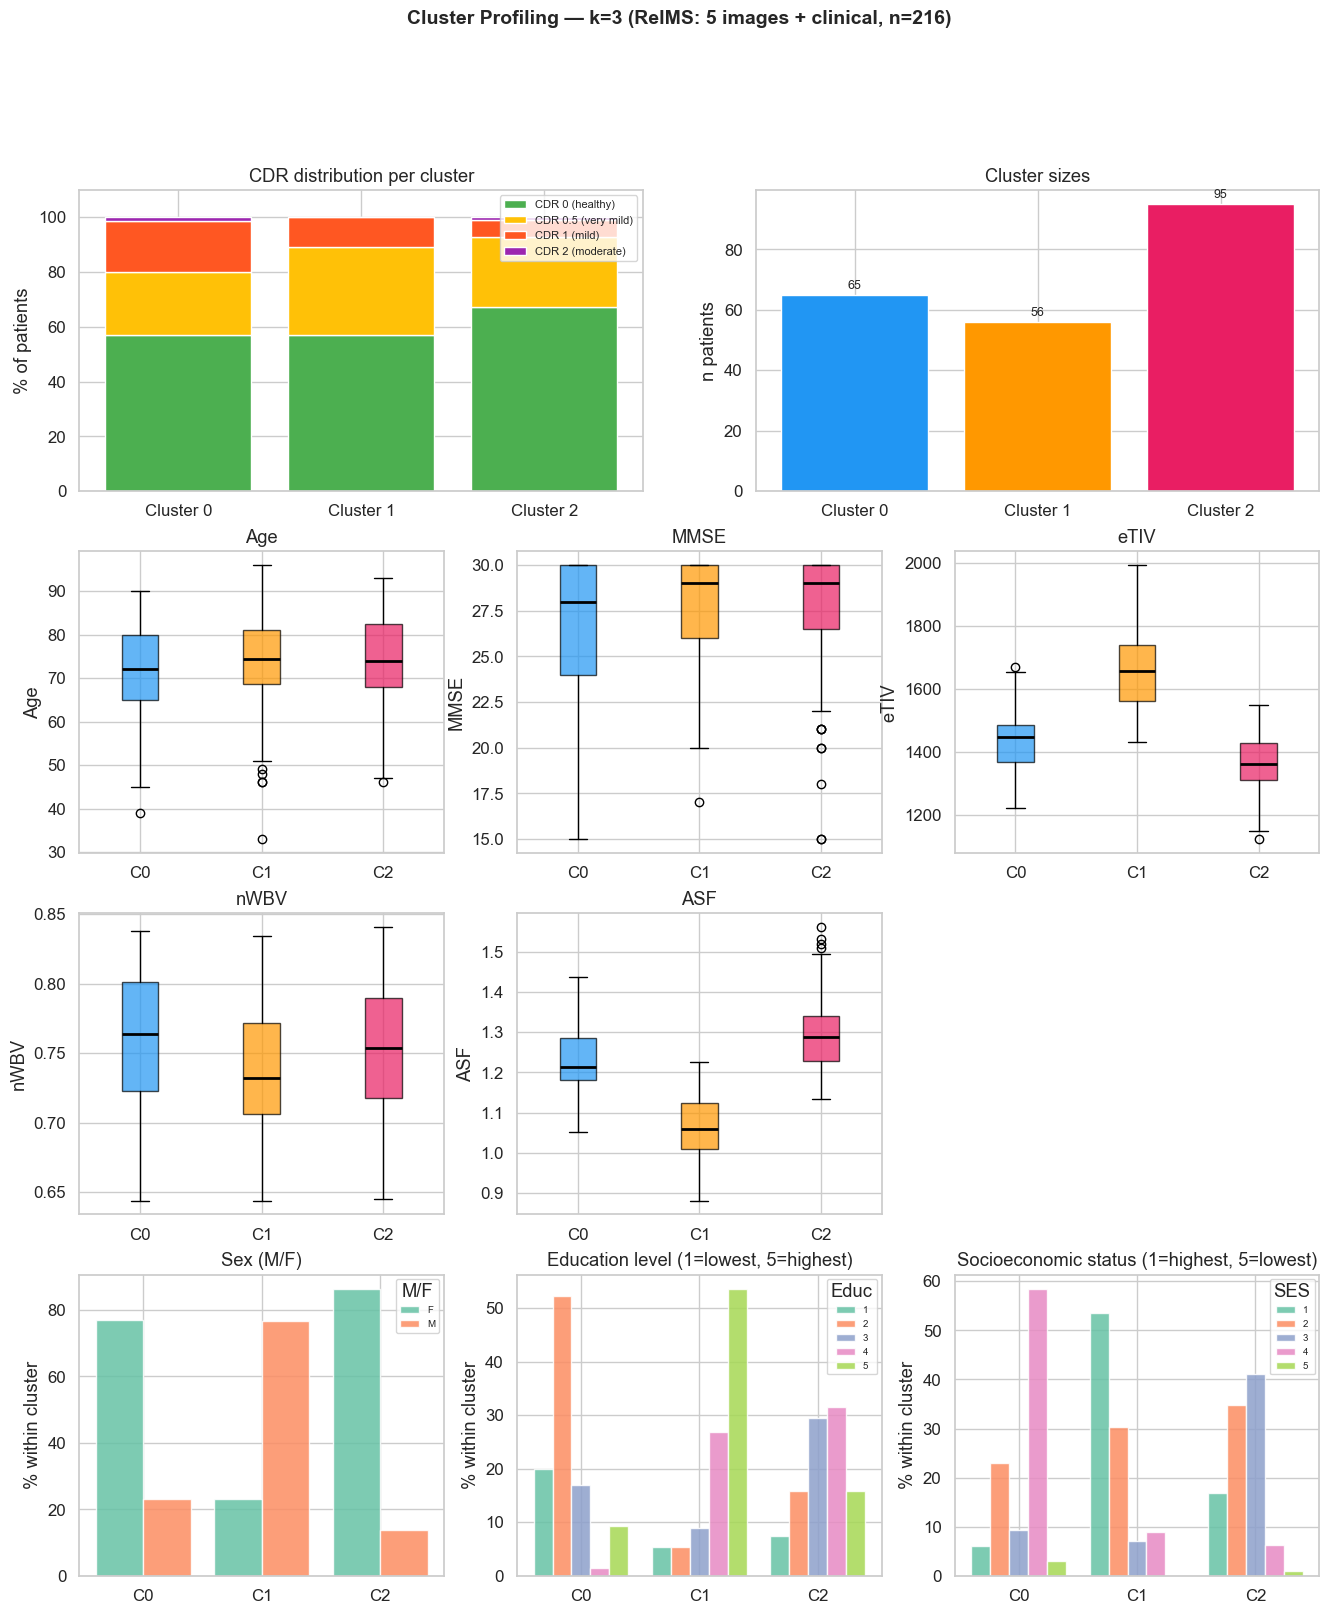

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\cluster_profile_k3.png


In [12]:
# ── k=3 figure ───────────────────────────────────────────────────────────────
k = 3
labels      = cluster_labels[k]
df_profile  = df_c.assign(cluster=labels)
cluster_ids = sorted(df_profile['cluster'].unique())

fig = plt.figure(figsize=(16, 18))
fig.suptitle(f'Cluster Profiling — k={k} (RelMS: 5 images + clinical, n=216)',
             fontsize=14, fontweight='bold', y=0.98)

# Row 1: CDR stacked bar + sizes
ax1 = fig.add_subplot(4, 2, 1)
plot_cdr_stacked(ax1, df_profile, cluster_ids)

ax2 = fig.add_subplot(4, 2, 2)
plot_cluster_sizes(ax2, df_profile, cluster_ids)

# Row 2: Age, MMSE, eTIV
for col_i, feat in enumerate(['Age', 'MMSE', 'eTIV'], start=1):
    ax = fig.add_subplot(4, 3, 3 + col_i)
    plot_boxplots(ax, df_profile, feat, cluster_ids)

# Row 3: nWBV, ASF, (empty)
ax7 = fig.add_subplot(4, 3, 7)
plot_boxplots(ax7, df_profile, 'nWBV', cluster_ids)
ax8 = fig.add_subplot(4, 3, 8)
plot_boxplots(ax8, df_profile, 'ASF', cluster_ids)
ax9 = fig.add_subplot(4, 3, 9)
ax9.axis('off')  # placeholder

# Row 4: M/F, Educ, SES
ax10 = fig.add_subplot(4, 3, 10)
plot_categorical_bars(ax10, df_profile, 'M/F', cluster_ids, title='Sex (M/F)')

ax11 = fig.add_subplot(4, 3, 11)
plot_categorical_bars(ax11, df_profile.assign(Educ=df_c['Educ'].astype(int)),
                      'Educ', cluster_ids,
                      title='Education level (1=lowest, 5=highest)')

ax12 = fig.add_subplot(4, 3, 12)
plot_categorical_bars(ax12, df_profile.assign(SES=df_c['SES'].astype(int)),
                      'SES', cluster_ids,
                      title='Socioeconomic status (1=highest, 5=lowest)')

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_k3 = os.path.join(NB_PADDED, 'cluster_profile_k3.png')
plt.savefig(out_k3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_k3}')

## 9 — Cluster mean heatmap

A single heatmap (z-scored) showing how each cluster's mean clinical profile
compares to the overall population mean. Useful for spotting which clusters skew
older, sicker, better educated, etc.

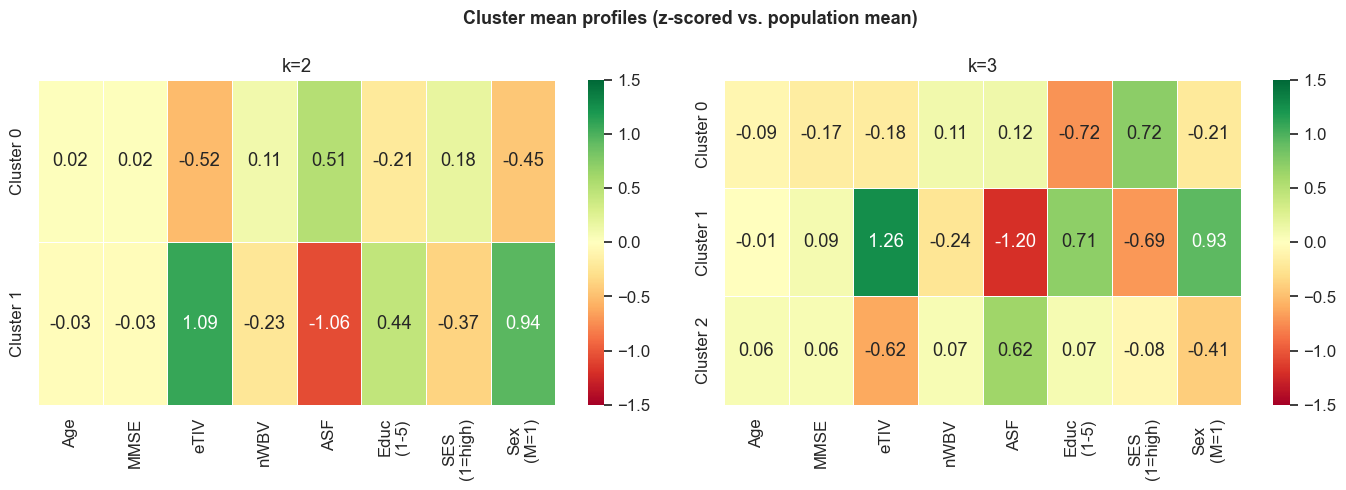

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\cluster_profile_heatmap.png


In [13]:
HEATMAP_FEATS = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'Educ', 'SES', 'MF']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster mean profiles (z-scored vs. population mean)',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, [2, 3]):
    labels     = cluster_labels[k]
    df_profile = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    # global mean & std for z-scoring
    pop_mean = df_c[HEATMAP_FEATS].mean()
    pop_std  = df_c[HEATMAP_FEATS].std().replace(0, 1)

    rows = []
    for c in cluster_ids:
        mask      = df_profile['cluster'] == c
        clust_mean = df_c.loc[mask, HEATMAP_FEATS].mean()
        z_scores  = (clust_mean - pop_mean) / pop_std
        rows.append(z_scores)

    heat_df = pd.DataFrame(rows, index=[f'Cluster {c}' for c in cluster_ids],
                           columns=HEATMAP_FEATS)

    feat_labels = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF',
                   'Educ\n(1-5)', 'SES\n(1=high)', 'Sex\n(M=1)']

    sns.heatmap(heat_df, annot=True, fmt='.2f', center=0,
                cmap='RdYlGn', vmin=-1.5, vmax=1.5,
                linewidths=0.5, ax=ax,
                xticklabels=feat_labels)
    ax.set_title(f'k={k}')
    ax.set_ylabel('')

plt.tight_layout()
out_heat = os.path.join(NB_PADDED, 'cluster_profile_heatmap.png')
plt.savefig(out_heat, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_heat}')

## 10 — Detailed CDR breakdown plot

Grouped bar chart (not stacked) so absolute proportions per CDR level are easier to compare.

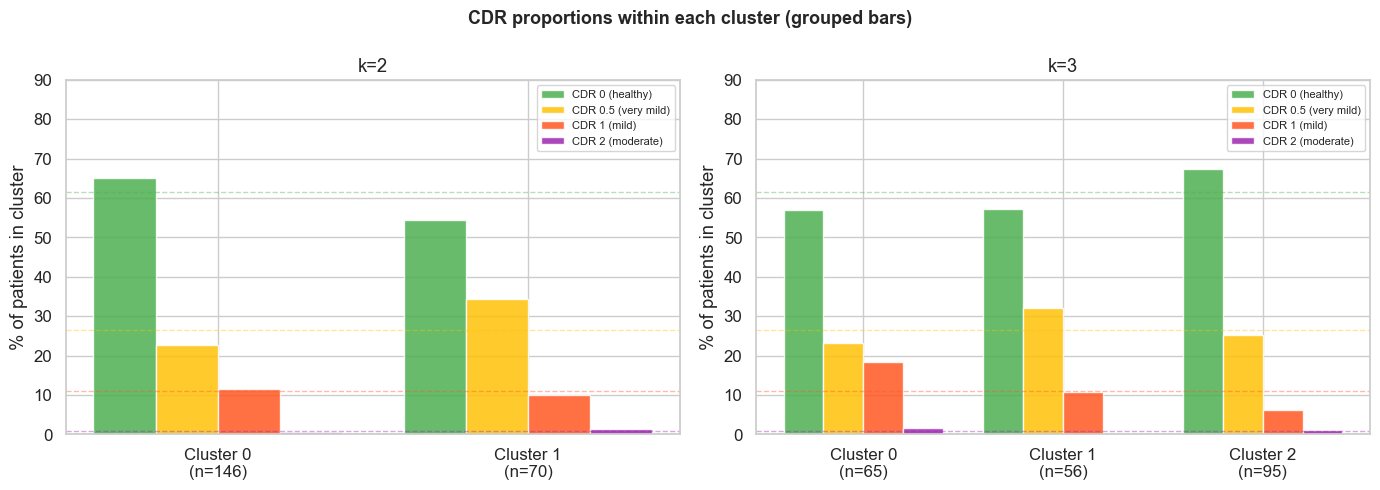

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\cluster_cdr_detail.png
(Dashed lines = overall population proportion for each CDR level)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('CDR proportions within each cluster (grouped bars)',
             fontsize=13, fontweight='bold')

cdr_order = [0.0, 0.5, 1.0, 2.0]

for ax, k in zip(axes, [2, 3]):
    labels      = cluster_labels[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    pct = pd.crosstab(df_profile['cluster'], df_profile['CDR'], normalize='index') * 100

    x     = np.arange(len(cluster_ids))
    width = 0.8 / len(cdr_order)

    for i, cdr in enumerate(cdr_order):
        if cdr not in pct.columns:
            continue
        vals = [pct.loc[c, cdr] if c in pct.index else 0.0 for c in cluster_ids]
        ax.bar(x + i * width - 0.4 + width / 2, vals, width,
               label=CDR_LABELS[cdr], color=CDR_COLORS[cdr], alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Cluster {c}\n(n={int((labels==c).sum())})' for c in cluster_ids])
    ax.set_ylabel('% of patients in cluster')
    ax.set_title(f'k={k}')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 90)

    # add overall reference lines
    for cdr, color in CDR_COLORS.items():
        if cdr not in pct.columns:
            continue
        overall_pct = (cdr_values == cdr).mean() * 100
        ax.axhline(overall_pct, color=color, linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
out_cdr = os.path.join(NB_PADDED, 'cluster_cdr_detail.png')
plt.savefig(out_cdr, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_cdr}')
print('(Dashed lines = overall population proportion for each CDR level)')

## 11 — Save profiling summary to CSV

In [15]:
rows = []
for k in [2, 3]:
    labels      = cluster_labels[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    # CDR proportions
    pct_cdr = pd.crosstab(df_profile['cluster'], df_profile['CDR'],
                          normalize='index').mul(100).round(2)

    for c in cluster_ids:
        mask = df_profile['cluster'] == c
        sub  = df_c[mask]
        row  = {
            'k':          k,
            'cluster':    c,
            'n':          int(mask.sum()),
            'pct_CDR0':   round(float(pct_cdr.loc[c, 0.0]) if 0.0 in pct_cdr.columns else 0.0, 1),
            'pct_CDR05':  round(float(pct_cdr.loc[c, 0.5]) if 0.5 in pct_cdr.columns else 0.0, 1),
            'pct_CDR1':   round(float(pct_cdr.loc[c, 1.0]) if 1.0 in pct_cdr.columns else 0.0, 1),
            'pct_CDR2':   round(float(pct_cdr.loc[c, 2.0]) if 2.0 in pct_cdr.columns else 0.0, 1),
            'mean_Age':   round(sub['Age'].mean(), 2),
            'std_Age':    round(sub['Age'].std(), 2),
            'mean_MMSE':  round(sub['MMSE'].mean(), 2),
            'std_MMSE':   round(sub['MMSE'].std(), 2),
            'mean_nWBV':  round(sub['nWBV'].mean(), 4),
            'std_nWBV':   round(sub['nWBV'].std(), 4),
            'mean_eTIV':  round(sub['eTIV'].mean(), 1),
            'mean_Educ':  round(sub['Educ'].mean(), 2),
            'mean_SES':   round(sub['SES'].mean(), 2),
            'pct_female': round((sub['M/F'] == 'F').mean() * 100, 1),
        }
        rows.append(row)

df_summary = pd.DataFrame(rows)
out_csv    = os.path.join(NB_PADDED, 'results_cluster_profiling.csv')
df_summary.to_csv(out_csv, index=False)

print('Profiling summary:')
print(df_summary.to_string(index=False))
print(f'\nSaved: {out_csv}')

Profiling summary:
 k  cluster   n  pct_CDR0  pct_CDR05  pct_CDR1  pct_CDR2  mean_Age  std_Age  mean_MMSE  std_MMSE  mean_nWBV  std_nWBV  mean_eTIV  mean_Educ  mean_SES  pct_female
 2        0 146      65.1       22.6      11.6       0.7     72.63    11.60      27.38      3.45     0.7558    0.0472     1374.9       2.95      2.69        88.4
 2        1  70      54.3       34.3      10.0       1.4     72.06    13.75      27.21      3.42     0.7394    0.0489     1633.3       3.81      2.07        22.9
 3        0  65      56.9       23.1      18.5       1.5     71.34    11.65      26.75      3.84     0.7558    0.0509     1429.6       2.28      3.29        76.9
 3        1  56      57.1       32.1      10.7       0.0     72.38    13.53      27.62      2.99     0.7387    0.0452     1660.6       4.18      1.71        23.2
 3        2  95      67.4       25.3       6.3       1.1     73.24    12.06      27.54      3.38     0.7538    0.0475     1359.4       3.33      2.40        86.3

Saved: C

## 12 — Cluster separation: PCA scatter (PC1 vs PC2)

PCA is applied directly to the feature matrix **X** (558 columns) to compress it into
2 dimensions. Each dot is one patient, coloured only by cluster assignment — no other
feature is overlaid.

PC1 explains 98.8% variance,  PC2 explains 0.6%


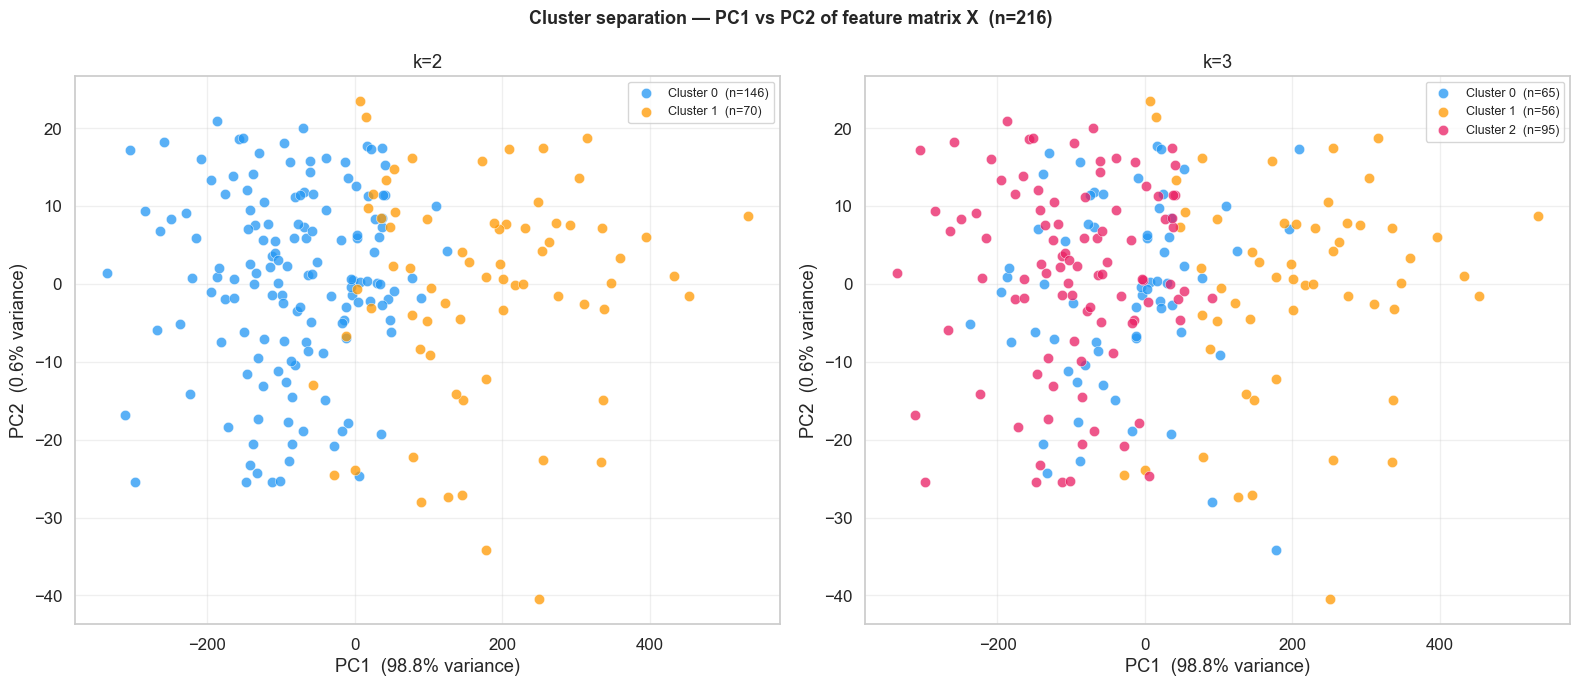

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\cluster_pca_separation_n216.png


In [16]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
X_2d    = pca_vis.fit_transform(X)   # X = 558-column feature matrix from above
var1    = pca_vis.explained_variance_ratio_[0] * 100
var2    = pca_vis.explained_variance_ratio_[1] * 100
print(f'PC1 explains {var1:.1f}% variance,  PC2 explains {var2:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Cluster separation — PC1 vs PC2 of feature matrix X  (n=216)',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, [2, 3]):
    labels      = cluster_labels[k]
    cluster_ids = sorted(set(labels))

    for c in cluster_ids:
        mask = labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   color=CLUSTER_COLORS[c],
                   label=f'Cluster {c}  (n={int(mask.sum())})',
                   s=55, alpha=0.75, edgecolors='white', linewidths=0.4)

    ax.set_xlabel(f'PC1  ({var1:.1f}% variance)')
    ax.set_ylabel(f'PC2  ({var2:.1f}% variance)')
    ax.set_title(f'k={k}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_pca = os.path.join(NB_PADDED, 'cluster_pca_separation_n216.png')
plt.savefig(out_pca, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_pca}')

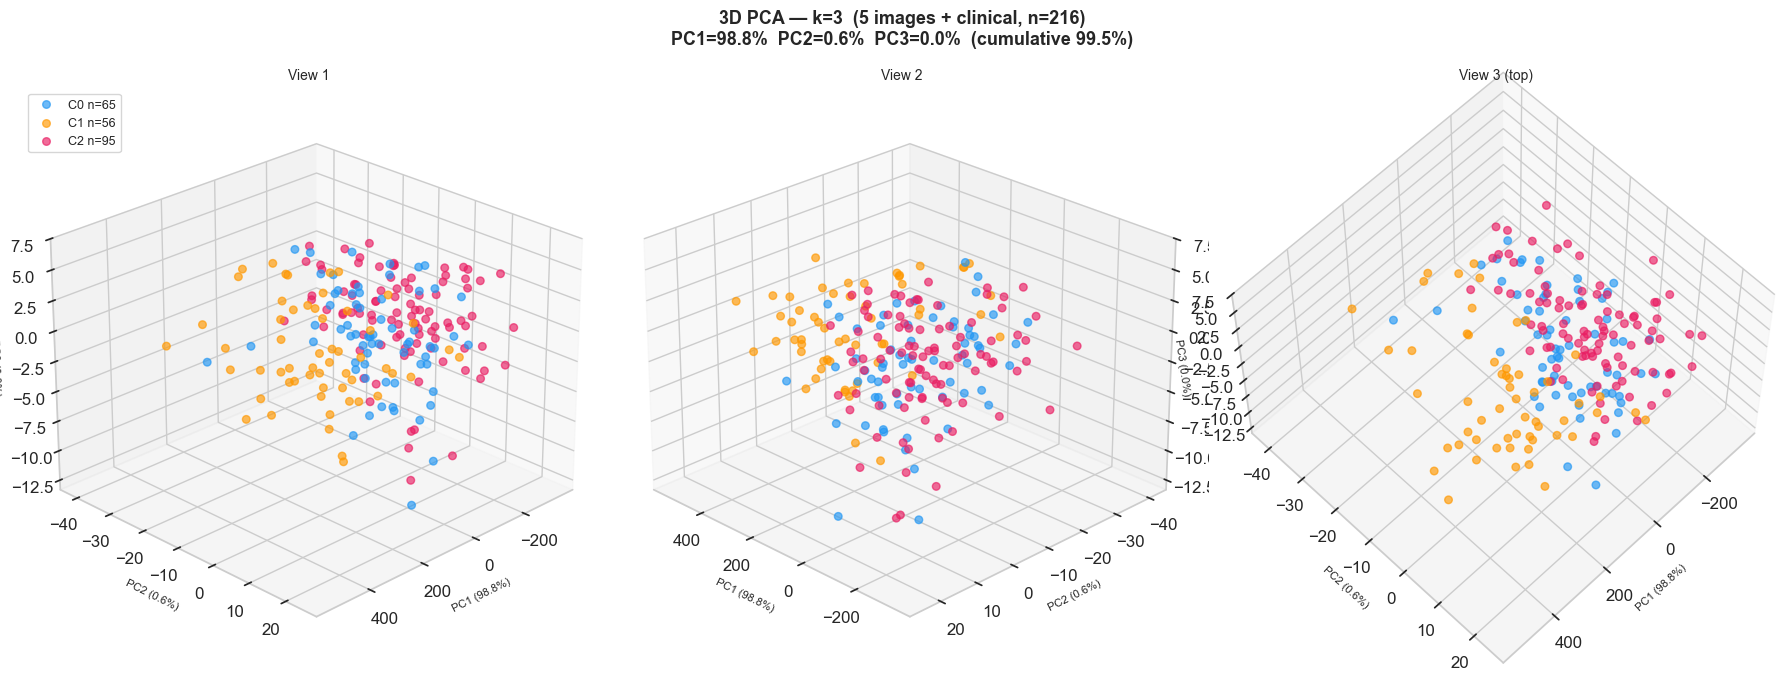

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\pca_3d_full_k3.png


In [17]:
# ── 3D PCA scatter — 5 images + clinical, k=3 ───────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

pca_3d_full = PCA(n_components=3, random_state=42)
X_3d_full   = pca_3d_full.fit_transform(X)
v3f = pca_3d_full.explained_variance_ratio_ * 100

k       = 3
labels  = cluster_labels[k]
c_ids   = sorted(set(labels))

fig = plt.figure(figsize=(18, 7))
fig.suptitle(f'3D PCA — k=3  (5 images + clinical, n=216)\n'
             f'PC1={v3f[0]:.1f}%  PC2={v3f[1]:.1f}%  PC3={v3f[2]:.1f}%  '
             f'(cumulative {sum(v3f):.1f}%)',
             fontsize=13, fontweight='bold')

for col, (elev, azim, title) in enumerate([(25, 45, 'View 1'),
                                            (25, 135, 'View 2'),
                                            (60, 45, 'View 3 (top)')]):
    ax = fig.add_subplot(1, 3, col+1, projection='3d')
    for c in c_ids:
        mask = labels == c
        ax.scatter(X_3d_full[mask, 0], X_3d_full[mask, 1], X_3d_full[mask, 2],
                   color=CLUSTER_COLORS[c], alpha=0.65, s=30,
                   label=f'C{c} n={mask.sum()}')
    ax.set_xlabel(f'PC1 ({v3f[0]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_ylabel(f'PC2 ({v3f[1]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_zlabel(f'PC3 ({v3f[2]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)
    if col == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
out = os.path.join(NB_PADDED, 'pca_3d_full_k3.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## 15 — Clinical-only clustering (n=216)

Same 216 complete-case patients, same RelMS method, but **no image features** —
clinical data only.

| Block | Features | Size | Distance |
|-------|----------|------|----------|
| Quantitative (p1) | Age, MMSE, eTIV, nWBV, ASF | 5 | euclidean |
| Multiclass (p3) | M/F, Educ, SES | 3 | hamming |

**Purpose**: baseline comparison. If clinical-only produces the same clusters as
images + clinical (sections 1–12), the images added no information. If the clusters
differ, the images contributed something beyond what clinical data alone captures.

In [18]:
# ── Feature matrix: clinical features only (no images) ───────────────────────
# df_c and QUANT_CLIN / MULTCLS_CLIN are already defined in sections 1-3 above

X_clin = np.concatenate([
    df_c[QUANT_CLIN].to_numpy(dtype=np.float64),       # 5 quant  → p1
    df_c[MULTCLS_CLIN].to_numpy(dtype=np.float64),      # 3 multi  → p3
], axis=1)

print(f'X_clin shape : {X_clin.shape}  (expected (216, 8))')
print(f'NaN in X_clin: {np.isnan(X_clin).sum()}')

# ── RelMS distance: one quantitative block of 5, no binary, 3 multiclass ─────
print('\nComputing RelMS distance matrix (clinical only) ...')
D_clin = related_metric_scaling_dist_matrix_faster(
    X=pd.DataFrame(X_clin),
    p1=[5],       # single quantitative block: Age, MMSE, eTIV, nWBV, ASF
    p2=0,
    p3=3,         # M/F, Educ, SES
    d1='euclidean',
    d2='sokal',
    d3='hamming',
    weights=None,
)
print(f'D_clin shape  : {D_clin.shape}')
print(f'Value range   : [{D_clin.min():.4f}, {D_clin.max():.4f}]')
print(f'NaN in D_clin : {np.isnan(D_clin).sum()}')
print(f'Symmetric     : {np.allclose(D_clin, D_clin.T)}')

X_clin shape : (216, 8)  (expected (216, 8))
NaN in X_clin: 0

Computing RelMS distance matrix (clinical only) ...
D_clin shape  : (216, 216)
Value range   : [0.0000, 8.5644]
NaN in D_clin : 0
Symmetric     : True


C:\Users\aregk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\robust_mixed_dist\mixed.py:1002: UserWarning: Gram matrix for block 3 is not PSD (min eig=-1.76e+01). Transformation applied.
  warnings.warn(


---
## 6b — Optimal k selection: Elbow, Silhouette and Davies-Bouldin

Three standard criteria to decide the best number of clusters, tested on both
distance matrices (all 5 images + clinical, and clinical-only), k=2 to k=8.

| Method | What it measures | Best k = |
|---|---|---|
| **Elbow** | kmedoids loss — diminishing returns after the bend | where curve flattens |
| **Silhouette** | How compact and separated clusters are (higher = better) | highest value |
| **Davies-Bouldin** | Ratio of within-cluster to between-cluster distances (lower = better) | lowest value |

In [19]:
from sklearn.metrics import davies_bouldin_score, silhouette_samples

K_RANGE = range(2, 9)

experiments_ksel = {
    'all 5img + clinical': D,
    'clinical only':       D_clin,
}

ksel_results = {}

for exp_name, D_mat in experiments_ksel.items():
    losses, sils, dbs = [], [], []
    for k in K_RANGE:
        res    = kmedoids.fasterpam(D_mat, medoids=k, random_state=42)
        labels = np.array(res.labels, dtype=int)
        sil    = silhouette_score(D_mat, labels, metric='precomputed')
        db     = davies_bouldin_score(D_mat, labels)
        losses.append(res.loss)
        sils.append(sil)
        dbs.append(db)
        print(f'  [{exp_name}] k={k}  loss={res.loss:.1f}  sil={sil:.4f}  DB={db:.4f}')
    ksel_results[exp_name] = {'loss': losses, 'sil': sils, 'db': dbs}
    print()

  [all 5img + clinical] k=2  loss=1569.4  sil=0.0262  DB=3.5095
  [all 5img + clinical] k=3  loss=1556.9  sil=0.0091  DB=6.3687
  [all 5img + clinical] k=4  loss=1545.9  sil=0.0079  DB=6.6218
  [all 5img + clinical] k=5  loss=1536.7  sil=0.0052  DB=6.1124
  [all 5img + clinical] k=6  loss=1527.7  sil=0.0056  DB=5.8004
  [all 5img + clinical] k=7  loss=1519.2  sil=0.0055  DB=5.3902
  [all 5img + clinical] k=8  loss=1510.8  sil=0.0041  DB=5.5439

  [clinical only] k=2  loss=1444.3  sil=0.0292  DB=3.2070
  [clinical only] k=3  loss=1432.1  sil=0.0130  DB=5.4509
  [clinical only] k=4  loss=1422.2  sil=0.0125  DB=5.5185
  [clinical only] k=5  loss=1413.9  sil=0.0095  DB=5.2355
  [clinical only] k=6  loss=1405.7  sil=0.0081  DB=4.7632
  [clinical only] k=7  loss=1398.3  sil=0.0074  DB=5.0956
  [clinical only] k=8  loss=1390.5  sil=0.0078  DB=4.7482



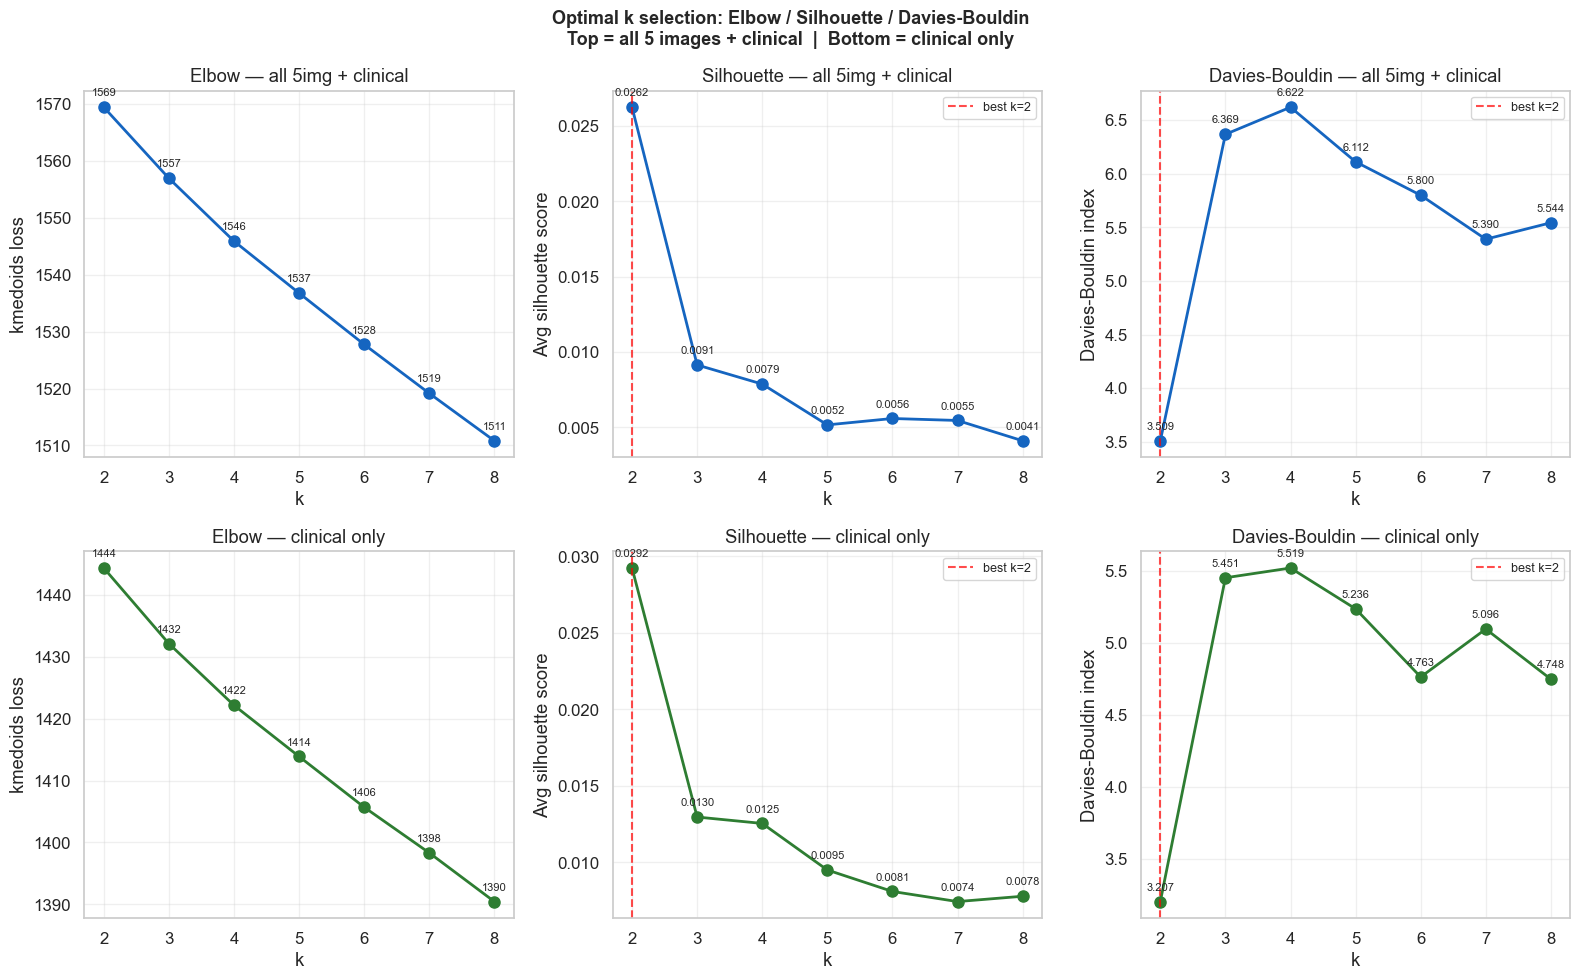

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\k_selection_criteria.png


In [20]:
# ── Elbow / Silhouette / Davies-Bouldin curves ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Optimal k selection: Elbow / Silhouette / Davies-Bouldin\n'
             'Top = all 5 images + clinical  |  Bottom = clinical only',
             fontsize=13, fontweight='bold')

exp_names  = list(ksel_results.keys())
ks         = list(K_RANGE)
row_colors = ['#1565C0', '#2E7D32']

for row, (exp_name, color) in enumerate(zip(exp_names, row_colors)):
    res = ksel_results[exp_name]

    # Elbow
    ax = axes[row, 0]
    ax.plot(ks, res['loss'], marker='o', color=color, linewidth=2, markersize=8)
    for k, v in zip(ks, res['loss']):
        ax.annotate(f'{v:.0f}', (k, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    ax.set_xlabel('k'); ax.set_ylabel('kmedoids loss')
    ax.set_title(f'Elbow — {exp_name}'); ax.set_xticks(ks); ax.grid(alpha=0.3)

    # Silhouette
    ax = axes[row, 1]
    ax.plot(ks, res['sil'], marker='o', color=color, linewidth=2, markersize=8)
    best_k_sil = ks[int(np.argmax(res['sil']))]
    ax.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'best k={best_k_sil}')
    for k, v in zip(ks, res['sil']):
        ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    ax.set_xlabel('k'); ax.set_ylabel('Avg silhouette score')
    ax.set_title(f'Silhouette — {exp_name}'); ax.set_xticks(ks)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)

    # Davies-Bouldin
    ax = axes[row, 2]
    ax.plot(ks, res['db'], marker='o', color=color, linewidth=2, markersize=8)
    best_k_db = ks[int(np.argmin(res['db']))]
    ax.axvline(best_k_db, color='red', linestyle='--', alpha=0.7, label=f'best k={best_k_db}')
    for k, v in zip(ks, res['db']):
        ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    ax.set_xlabel('k'); ax.set_ylabel('Davies-Bouldin index')
    ax.set_title(f'Davies-Bouldin — {exp_name}'); ax.set_xticks(ks)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
out = os.path.join(NB_PADDED, 'k_selection_criteria.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

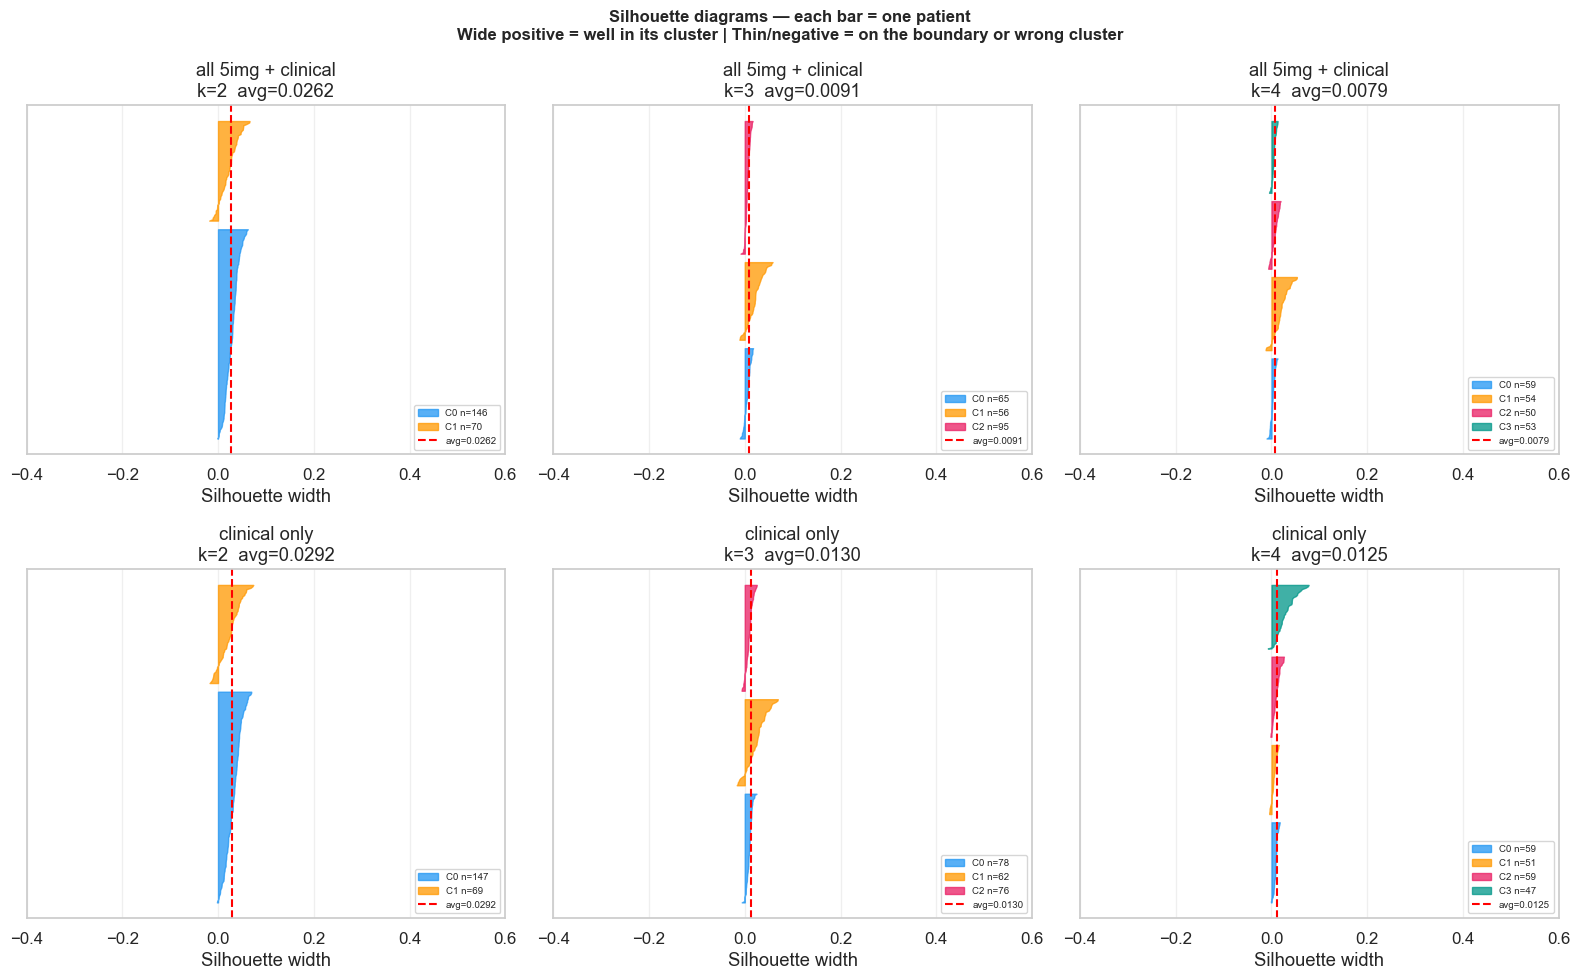

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\silhouette_diagrams.png


In [21]:
# ── Silhouette diagrams: per-patient widths for k=2, 3, 4 ───────────────────
COLORS_4 = ['#2196F3', '#FF9800', '#E91E63', '#009688']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Silhouette diagrams — each bar = one patient\n'
             'Wide positive = well in its cluster | Thin/negative = on the boundary or wrong cluster',
             fontsize=12, fontweight='bold')

for row, (exp_name, D_mat) in enumerate(experiments_ksel.items()):
    for col, k in enumerate([2, 3, 4]):
        ax    = axes[row, col]
        res   = kmedoids.fasterpam(D_mat, medoids=k, random_state=42)
        labels = np.array(res.labels, dtype=int)
        sil_vals = silhouette_samples(D_mat, labels, metric='precomputed')
        avg_sil  = sil_vals.mean()

        y_lower = 10
        for c in sorted(set(labels)):
            c_sil = np.sort(sil_vals[labels == c])
            size  = len(c_sil)
            ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, c_sil,
                             alpha=0.75, color=COLORS_4[c], label=f'C{c} n={size}')
            y_lower += size + 5

        ax.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5,
                   label=f'avg={avg_sil:.4f}')
        ax.set_xlabel('Silhouette width')
        ax.set_title(f'{exp_name}\nk={k}  avg={avg_sil:.4f}')
        ax.legend(fontsize=7, loc='lower right')
        ax.set_xlim(-0.4, 0.6); ax.set_yticks([]); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
out = os.path.join(NB_PADDED, 'silhouette_diagrams.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [22]:
# ── Summary and recommendation ───────────────────────────────────────────────
print('=' * 65)
print('  K-SELECTION SUMMARY')
print('=' * 65)
for exp_name in exp_names:
    res = ksel_results[exp_name]
    ks  = list(K_RANGE)
    best_k_sil = ks[int(np.argmax(res['sil']))]
    best_k_db  = ks[int(np.argmin(res['db']))]
    print(f'\n  {exp_name}')
    print(f'  {"k":<4}  {"loss":>8}  {"silhouette":>12}  {"davies-bouldin":>15}')
    print('  ' + '-' * 45)
    for i, k in enumerate(ks):
        tags = []
        if k == best_k_sil: tags.append('best sil')
        if k == best_k_db:  tags.append('best DB')
        tag = f'  ← {", ".join(tags)}' if tags else ''
        print(f'  {k:<4}  {res["loss"][i]:>8.1f}  {res["sil"][i]:>12.4f}  {res["db"][i]:>15.4f}{tag}')
    print(f'\n  Silhouette recommends k={best_k_sil}')
    print(f'  Davies-Bouldin recommends k={best_k_db}')

  K-SELECTION SUMMARY

  all 5img + clinical
  k         loss    silhouette   davies-bouldin
  ---------------------------------------------
  2       1569.4        0.0262           3.5095  ← best sil, best DB
  3       1556.9        0.0091           6.3687
  4       1545.9        0.0079           6.6218
  5       1536.7        0.0052           6.1124
  6       1527.7        0.0056           5.8004
  7       1519.2        0.0055           5.3902
  8       1510.8        0.0041           5.5439

  Silhouette recommends k=2
  Davies-Bouldin recommends k=2

  clinical only
  k         loss    silhouette   davies-bouldin
  ---------------------------------------------
  2       1444.3        0.0292           3.2070  ← best sil, best DB
  3       1432.1        0.0130           5.4509
  4       1422.2        0.0125           5.5185
  5       1413.9        0.0095           5.2355
  6       1405.7        0.0081           4.7632
  7       1398.3        0.0074           5.0956
  8       1390.5   

In [23]:
# ── Cluster k=3 and k=4 ──────────────────────────────────────────────────────
cluster_labels_clin = {}

for k in [2, 3]:
    result = kmedoids.fasterpam(D_clin, medoids=k, random_state=42)
    cluster_labels_clin[k] = np.array(result.labels, dtype=int)
    sizes = {c: int((cluster_labels_clin[k] == c).sum())
             for c in sorted(set(cluster_labels_clin[k]))}
    print(f'k={k}  loss={result.loss:.4f}  sizes={sizes}')

# ── Evaluation ────────────────────────────────────────────────────────────────
print()
for k in [2, 3]:
    labels  = cluster_labels_clin[k]
    sil     = silhouette_score(D_clin, labels, metric='precomputed')
    ari     = adjusted_rand_score(cdr_int, labels)
    nmi     = normalized_mutual_info_score(cdr_int, labels)
    df_ev   = pd.DataFrame({'cluster': labels, 'CDR': cdr_values})
    pct_tab = pd.crosstab(df_ev['cluster'], df_ev['CDR'], normalize='index').mul(100)
    spread  = float(pct_tab.get(0.0, pd.Series(0.0, index=pct_tab.index)).pipe(
                   lambda s: s.max() - s.min()))
    print(f'k={k}: sil={sil:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}  spread={spread:.2f}%')

k=2  loss=1444.3121  sizes={np.int64(0): 147, np.int64(1): 69}
k=3  loss=1432.1052  sizes={np.int64(0): 78, np.int64(1): 62, np.int64(2): 76}

k=2: sil=0.0292  ARI=0.0245  NMI=0.0063  spread=9.55%
k=3: sil=0.0130  ARI=0.0177  NMI=0.0301  spread=21.73%


In [24]:
# ── Profiling tables (clinical only) ─────────────────────────────────────────
for k in [2, 3]:
    labels      = cluster_labels_clin[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    print(f'\n{"="*70}')
    print(f'  CLINICAL-ONLY PROFILING — k={k}')
    print(f'{"="*70}')
    print('\nCluster sizes:')
    for c, n in df_profile['cluster'].value_counts().sort_index().items():
        print(f'  Cluster {c}: n={n}')

    print('\nQuantitative features (mean ± std):')
    header = 'Feature      ' + '  '.join(f'  Cluster {c}   ' for c in cluster_ids)
    print(header)
    print('-' * len(header))
    for feat in QUANT_DISPLAY:
        parts = [f'{df_profile.loc[df_profile["cluster"]==c, feat].mean():6.2f} ± '
                 f'{df_profile.loc[df_profile["cluster"]==c, feat].std():5.2f}'
                 for c in cluster_ids]
        print(f'{feat:<12} ' + '  '.join(parts))

    print('\nCDR distribution (row %):')
    pct = pd.crosstab(df_profile['cluster'], df_profile['CDR'],
                      normalize='index').mul(100).round(1)
    print(pct.to_string())

    print('\nM/F (% female):')
    for c in cluster_ids:
        sub = df_profile.loc[df_profile['cluster'] == c, 'M/F']
        print(f'  Cluster {c}: {(sub=="F").mean()*100:.1f}% female')


  CLINICAL-ONLY PROFILING — k=2

Cluster sizes:
  Cluster 0: n=147
  Cluster 1: n=69

Quantitative features (mean ± std):
Feature        Cluster 0       Cluster 1   
-------------------------------------------
Age           72.27 ± 11.76   72.83 ± 13.49
MMSE          27.26 ±  3.55   27.46 ±  3.21
eTIV         1376.97 ± 94.70  1632.64 ± 130.67
nWBV           0.76 ±  0.05    0.74 ±  0.05
ASF            1.28 ±  0.09    1.08 ±  0.09
Educ           2.93 ±  1.23    3.88 ±  1.32
SES            2.73 ±  1.03    1.99 ±  1.14

CDR distribution (row %):
CDR       0.0   0.5   1.0  2.0
cluster                       
0        64.6  23.8  10.9  0.7
1        55.1  31.9  11.6  1.4

M/F (% female):
  Cluster 0: 87.8% female
  Cluster 1: 23.2% female

  CLINICAL-ONLY PROFILING — k=3

Cluster sizes:
  Cluster 0: n=78
  Cluster 1: n=62
  Cluster 2: n=76

Quantitative features (mean ± std):
Feature        Cluster 0       Cluster 1       Cluster 2   
----------------------------------------------------------

C:\Users\aregk\AppData\Local\Temp\ipykernel_23520\3633838388.py:33: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


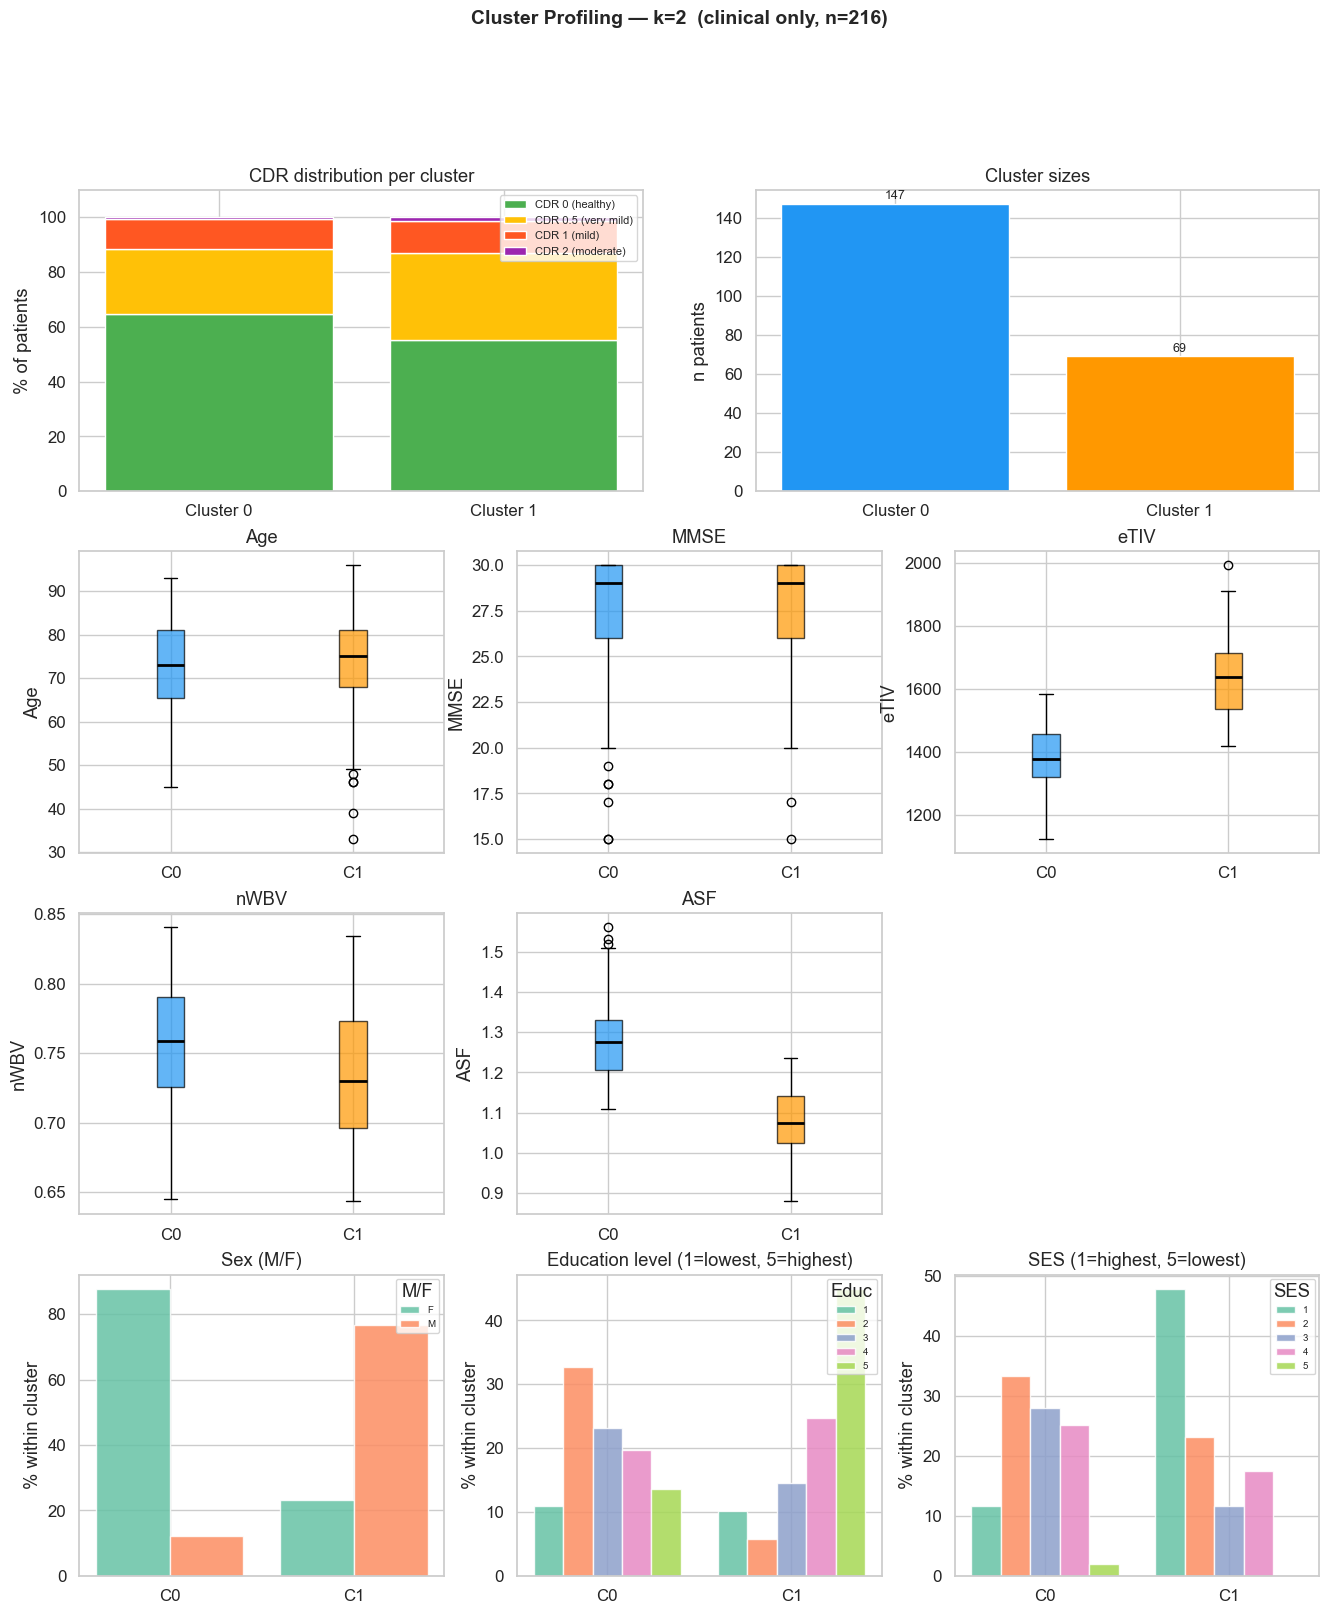

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\clinical_only_profile_k2.png


C:\Users\aregk\AppData\Local\Temp\ipykernel_23520\3633838388.py:33: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


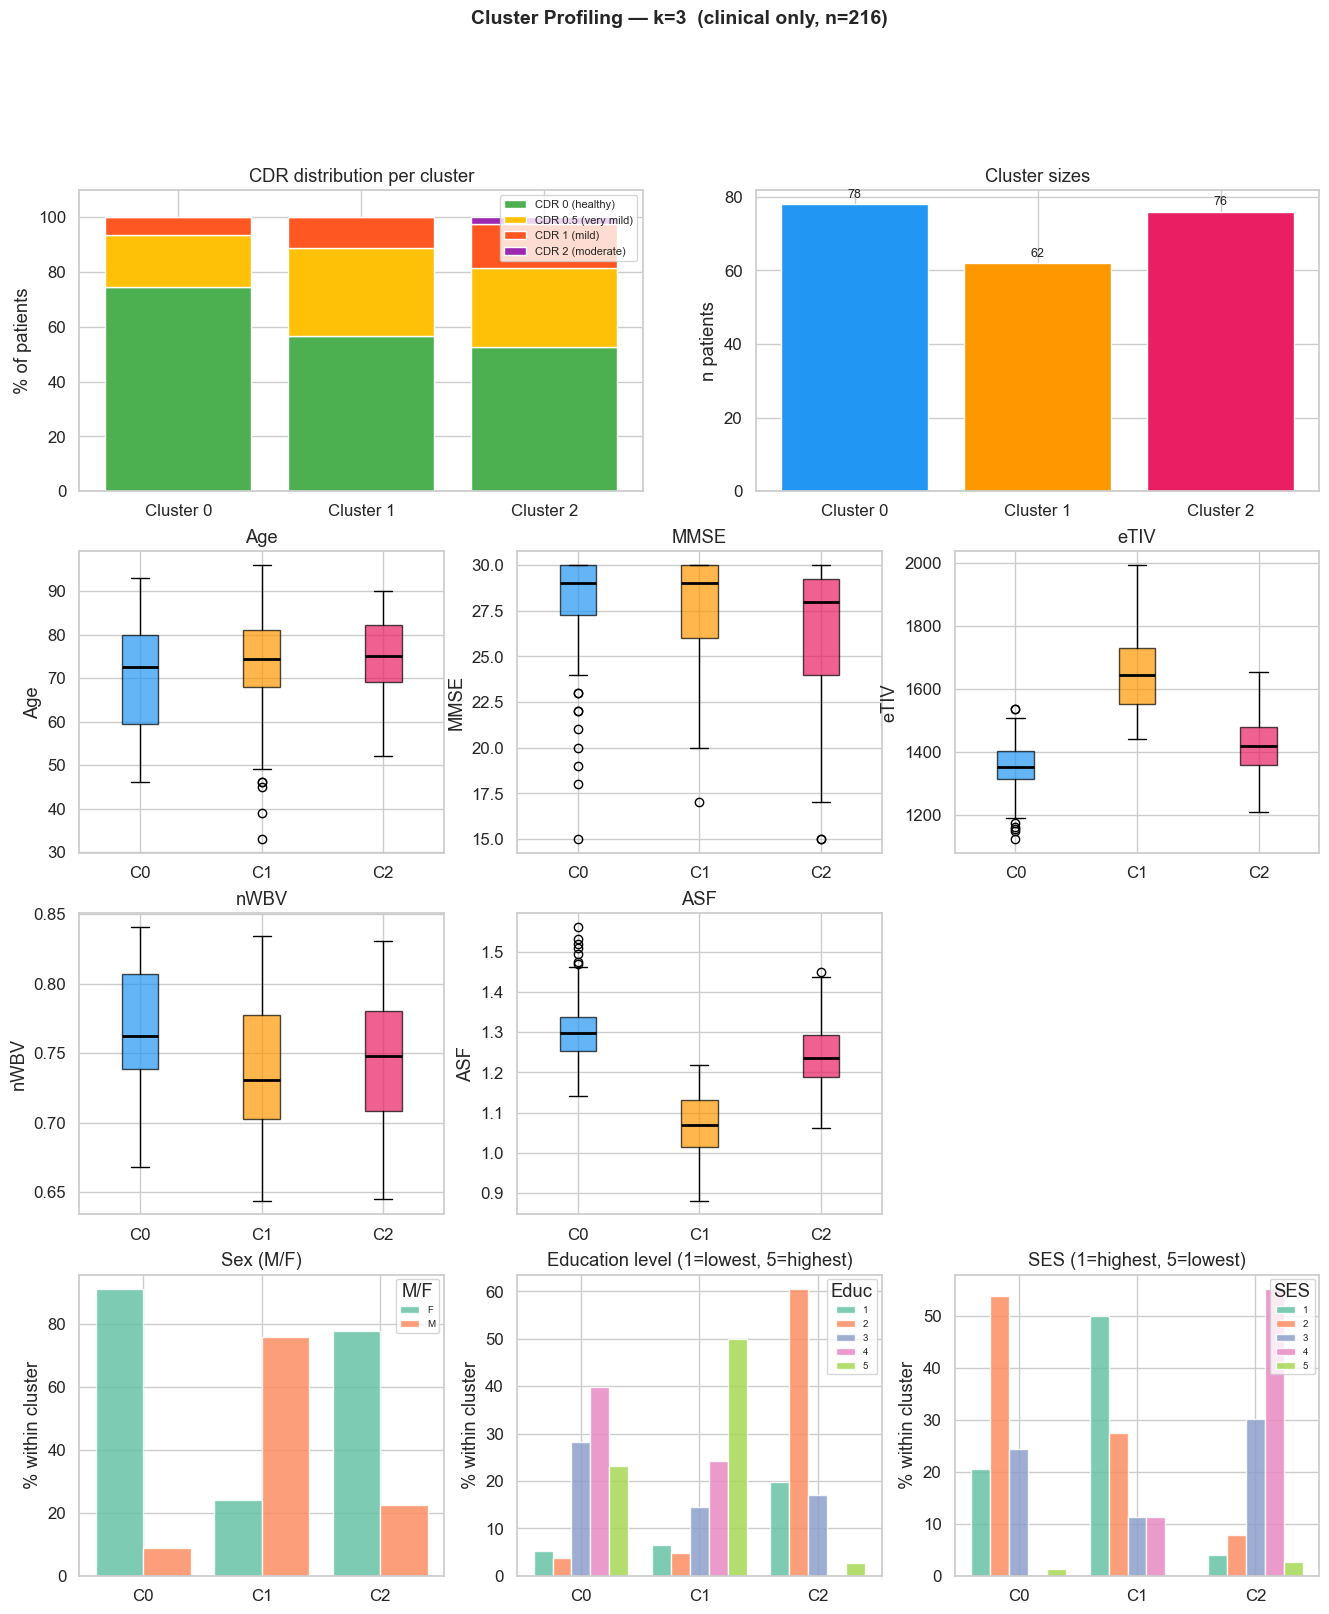

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\clinical_only_profile_k3.png


In [25]:
# ── Profiling visualisations (clinical only) ─────────────────────────────────
for k in [2, 3]:
    labels      = cluster_labels_clin[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    fig = plt.figure(figsize=(16, 18))
    fig.suptitle(f'Cluster Profiling — k={k}  (clinical only, n=216)',
                 fontsize=14, fontweight='bold', y=0.98)

    ax1 = fig.add_subplot(4, 2, 1)
    plot_cdr_stacked(ax1, df_profile, cluster_ids)

    ax2 = fig.add_subplot(4, 2, 2)
    plot_cluster_sizes(ax2, df_profile, cluster_ids)

    for col_i, feat in enumerate(['Age', 'MMSE', 'eTIV'], start=1):
        plot_boxplots(fig.add_subplot(4, 3, 3 + col_i), df_profile, feat, cluster_ids)

    plot_boxplots(fig.add_subplot(4, 3, 7), df_profile, 'nWBV', cluster_ids)
    plot_boxplots(fig.add_subplot(4, 3, 8), df_profile, 'ASF',  cluster_ids)
    fig.add_subplot(4, 3, 9).axis('off')

    plot_categorical_bars(fig.add_subplot(4, 3, 10), df_profile,
                          'M/F', cluster_ids, title='Sex (M/F)')
    plot_categorical_bars(fig.add_subplot(4, 3, 11),
                          df_profile.assign(Educ=df_c['Educ'].astype(int)),
                          'Educ', cluster_ids, title='Education level (1=lowest, 5=highest)')
    plot_categorical_bars(fig.add_subplot(4, 3, 12),
                          df_profile.assign(SES=df_c['SES'].astype(int)),
                          'SES', cluster_ids, title='SES (1=highest, 5=lowest)')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(NB_PADDED, f'clinical_only_profile_k{k}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

PC1 explains 99.4%,  PC2 explains 0.6%


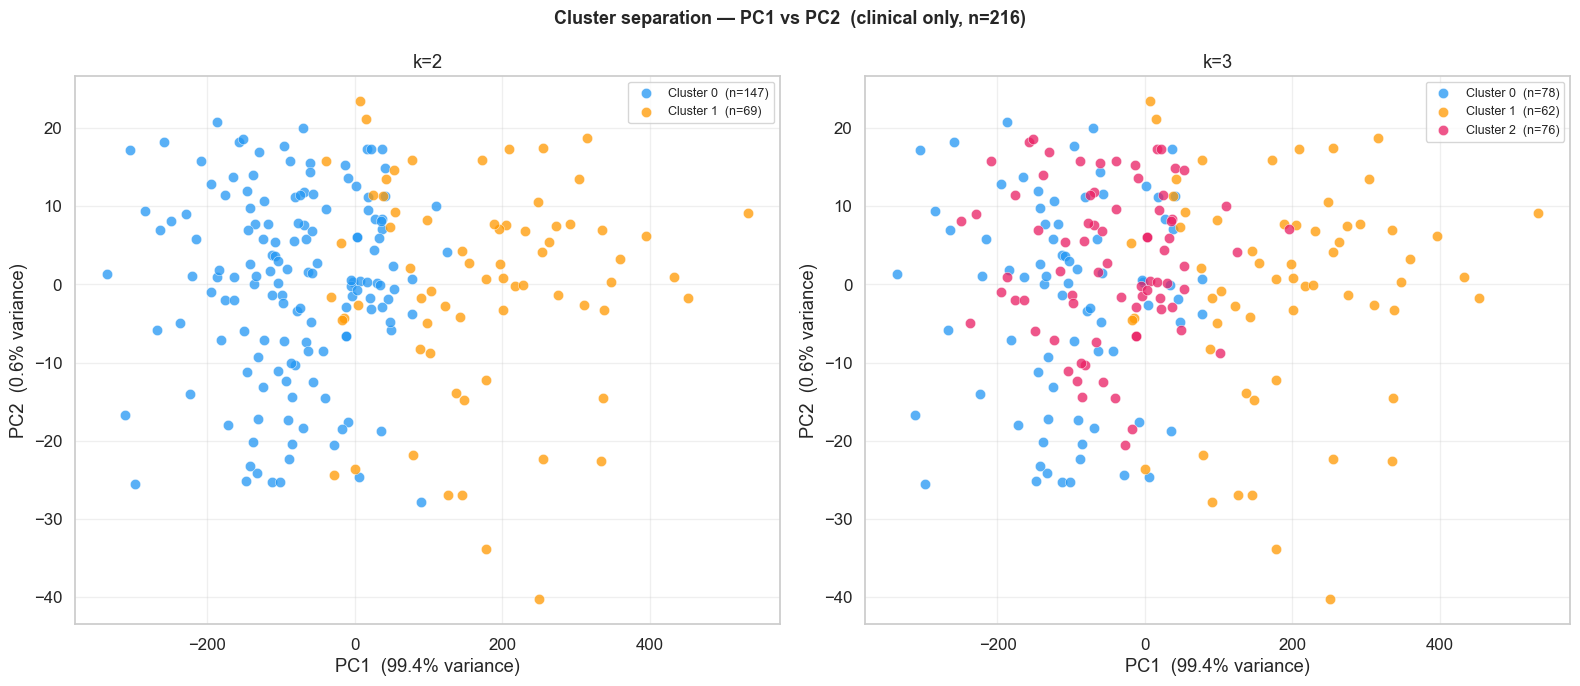

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\clinical_only_pca_scatter.png


In [26]:
# ── PCA scatter — clinical only ───────────────────────────────────────────────
pca_clin = PCA(n_components=2, random_state=42)
X_clin_2d = pca_clin.fit_transform(X_clin)
var1_c = pca_clin.explained_variance_ratio_[0] * 100
var2_c = pca_clin.explained_variance_ratio_[1] * 100
print(f'PC1 explains {var1_c:.1f}%,  PC2 explains {var2_c:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Cluster separation — PC1 vs PC2  (clinical only, n=216)',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, [2, 3]):
    labels      = cluster_labels_clin[k]
    cluster_ids = sorted(set(labels))

    for c in cluster_ids:
        mask = labels == c
        ax.scatter(X_clin_2d[mask, 0], X_clin_2d[mask, 1],
                   color=CLUSTER_COLORS[c],
                   label=f'Cluster {c}  (n={int(mask.sum())})',
                   s=55, alpha=0.75, edgecolors='white', linewidths=0.4)

    ax.set_xlabel(f'PC1  ({var1_c:.1f}% variance)')
    ax.set_ylabel(f'PC2  ({var2_c:.1f}% variance)')
    ax.set_title(f'k={k}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(NB_PADDED, 'clinical_only_pca_scatter.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

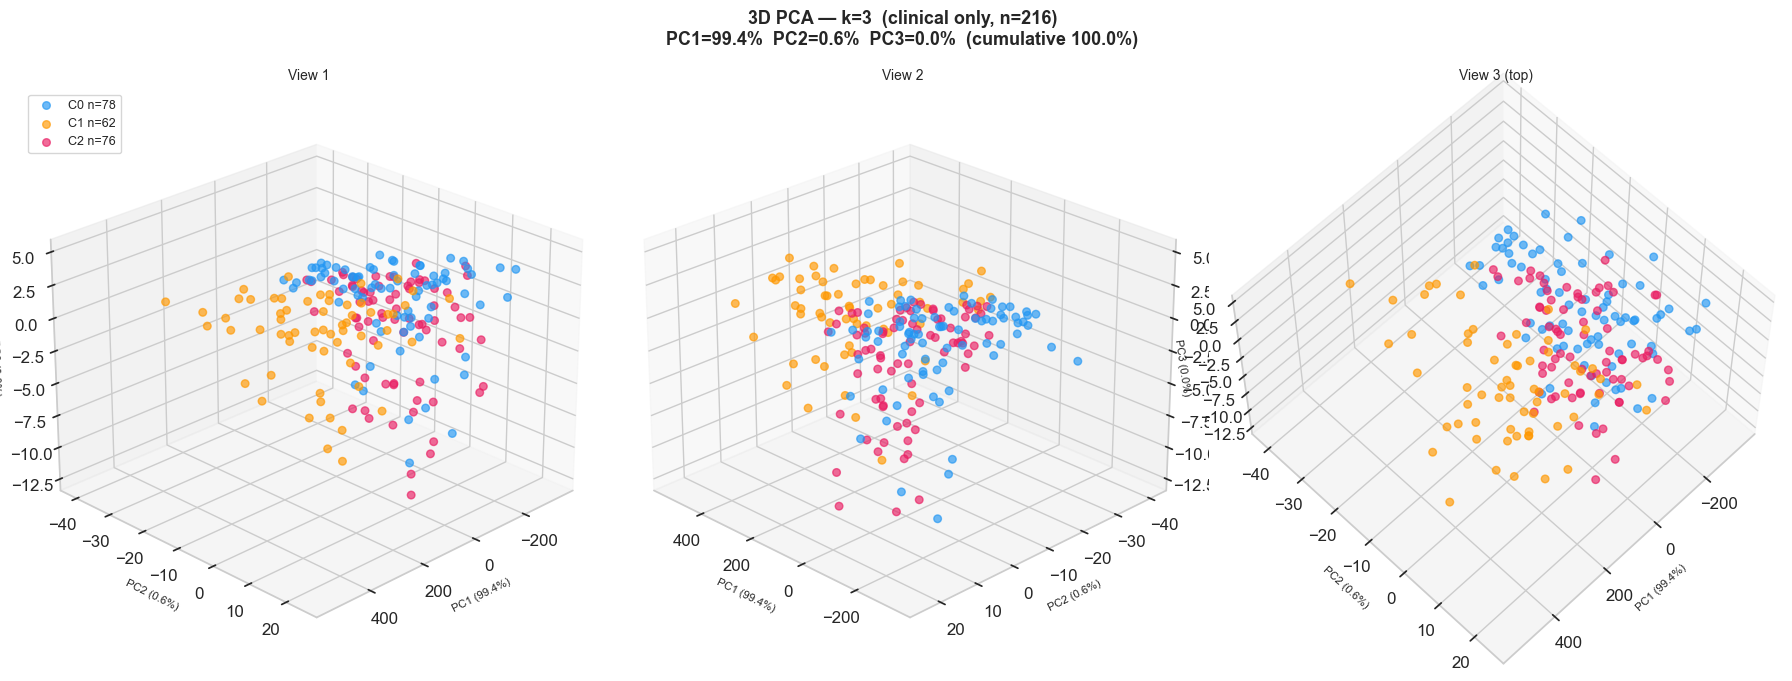

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\pca_3d_clinical_k3.png


In [27]:
# ── 3D PCA scatter — clinical only, k=3 ─────────────────────────────────────
pca_3d_clin = PCA(n_components=3, random_state=42)
X_3d_clin   = pca_3d_clin.fit_transform(X_clin)
v3c = pca_3d_clin.explained_variance_ratio_ * 100

k       = 3
labels  = cluster_labels_clin[k]
c_ids   = sorted(set(labels))

fig = plt.figure(figsize=(18, 7))
fig.suptitle(f'3D PCA — k=3  (clinical only, n=216)\n'
             f'PC1={v3c[0]:.1f}%  PC2={v3c[1]:.1f}%  PC3={v3c[2]:.1f}%  '
             f'(cumulative {sum(v3c):.1f}%)',
             fontsize=13, fontweight='bold')

for col, (elev, azim, title) in enumerate([(25, 45, 'View 1'),
                                            (25, 135, 'View 2'),
                                            (60, 45, 'View 3 (top)')]):
    ax = fig.add_subplot(1, 3, col+1, projection='3d')
    for c in c_ids:
        mask = labels == c
        ax.scatter(X_3d_clin[mask, 0], X_3d_clin[mask, 1], X_3d_clin[mask, 2],
                   color=CLUSTER_COLORS[c], alpha=0.65, s=30,
                   label=f'C{c} n={mask.sum()}')
    ax.set_xlabel(f'PC1 ({v3c[0]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_ylabel(f'PC2 ({v3c[1]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_zlabel(f'PC3 ({v3c[2]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)
    if col == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
out = os.path.join(NB_PADDED, 'pca_3d_clinical_k3.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## Images Only (no clinical) — 5 images, Euclidean distance

All five image types concatenated (PCA-reduced), **no clinical features**.
Distance metric: Euclidean (appropriate since all 550 features are PCA components on the same scale after per-image PCA).

This lets us see what the imaging data alone groups — without any clinical signal mixed in.

k=2 is statistically optimal (from the k-selection analysis above). k=3 is shown for clinical comparison.

In [28]:
# ── Feature matrix: 5 images only ───────────────────────────────────────────
from sklearn.metrics import pairwise_distances

X_img = np.concatenate([
    pca_blocks['cor'],
    pca_blocks['gfc_sag'],
    pca_blocks['gfc_tra'],
    pca_blocks['masked_tra'],
    pca_blocks['sbj_sag'],
], axis=1)   # shape (216, 550)

D_img = pairwise_distances(X_img, metric='euclidean')

print(f'X_img shape : {X_img.shape}')
print(f'D_img range : [{D_img.min():.2f}, {D_img.max():.2f}]')

X_img shape : (216, 550)
D_img range : [0.00, 21.42]


In [29]:
# ── Cluster k=2, k=3 ────────────────────────────────────────────────────────
cluster_labels_img = {}

for k in [2, 3]:
    result = kmedoids.fasterpam(D_img, medoids=k, random_state=42)
    cluster_labels_img[k] = np.array(result.labels, dtype=int)
    sizes = {c: int((cluster_labels_img[k] == c).sum()) for c in sorted(set(cluster_labels_img[k]))}
    sil   = silhouette_score(D_img, cluster_labels_img[k], metric='precomputed')
    ari   = adjusted_rand_score(cdr_int, cluster_labels_img[k])
    print(f'k={k}  loss={result.loss:.1f}  sil={sil:.4f}  ARI vs CDR={ari:.4f}  sizes={sizes}')

k=2  loss=3226.5  sil=0.0510  ARI vs CDR=-0.0040  sizes={np.int64(0): 81, np.int64(1): 135}
k=3  loss=3170.7  sil=0.0376  ARI vs CDR=-0.0205  sizes={np.int64(0): 35, np.int64(1): 100, np.int64(2): 81}


In [30]:
# ── PC1-PC5 profiling (images only) ─────────────────────────────────────────
# The image clusters are built from PCA components, so we compare those.
# Clinical features are shown only as external labels to help interpret clusters.

from sklearn.decomposition import PCA as _PCA

pca_top5 = _PCA(n_components=5, random_state=42)
X_img_top5 = pca_top5.fit_transform(X_img)
var5 = pca_top5.explained_variance_ratio_ * 100
cum5 = var5.cumsum()

print('Top 5 PCs of image space:')
for i in range(5):
    print(f'  PC{i+1}: {var5[i]:.2f}% variance  (cumulative {cum5[i]:.2f}%)')
print()

for k in [2, 3]:
    labels      = cluster_labels_img[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    print(f'{"="*70}')
    print(f'  IMAGES-ONLY PROFILING — k={k}  (n=216, Euclidean)')
    print(f'{"="*70}')
    print('\nCluster sizes:')
    for c, n in df_profile['cluster'].value_counts().sort_index().items():
        print(f'  Cluster {c}: n={n}')

    print('\nTop-5 image PCA components (mean ± std per cluster):')
    header = 'Component         ' + '  '.join(f'  Cluster {c}   ' for c in cluster_ids)
    print(header)
    print('-' * len(header))
    for i in range(5):
        vals = X_img_top5[:, i]
        parts = [f'{vals[labels==c].mean():7.3f} ± {vals[labels==c].std():5.3f}' for c in cluster_ids]
        print(f'PC{i+1} ({var5[i]:5.2f}% var)  ' + '  '.join(parts))

    print('\nExternal labels (not used in clustering):')
    print('  CDR distribution (row %):')
    pct = pd.crosstab(df_profile['cluster'], df_profile['CDR'], normalize='index').mul(100).round(1)
    print(pct.to_string())
    print('  M/F (% female):')
    for c in cluster_ids:
        sub = df_profile.loc[df_profile['cluster']==c, 'M/F']
        print(f'    Cluster {c}: {(sub=="F").mean()*100:.1f}% female')
    print()

Top 5 PCs of image space:
  PC1: 8.18% variance  (cumulative 8.18%)
  PC2: 4.80% variance  (cumulative 12.98%)
  PC3: 4.24% variance  (cumulative 17.22%)
  PC4: 3.09% variance  (cumulative 20.31%)
  PC5: 2.82% variance  (cumulative 23.13%)

  IMAGES-ONLY PROFILING — k=2  (n=216, Euclidean)

Cluster sizes:
  Cluster 0: n=81
  Cluster 1: n=135

Top-5 image PCA components (mean ± std per cluster):
Component           Cluster 0       Cluster 1   
------------------------------------------------
PC1 ( 8.18% var)    3.441 ± 1.494   -2.064 ± 2.460
PC2 ( 4.80% var)    0.828 ± 2.753   -0.497 ± 2.407
PC3 ( 4.24% var)   -0.596 ± 1.978    0.358 ± 2.654
PC4 ( 3.09% var)   -0.207 ± 1.879    0.124 ± 2.217
PC5 ( 2.82% var)    0.246 ± 1.818   -0.147 ± 2.102

External labels (not used in clustering):
  CDR distribution (row %):
CDR       0.0   0.5   1.0  2.0
cluster                       
0        63.0  23.5  11.1  2.5
1        60.7  28.1  11.1  0.0
  M/F (% female):
    Cluster 0: 58.0% female
    Clus

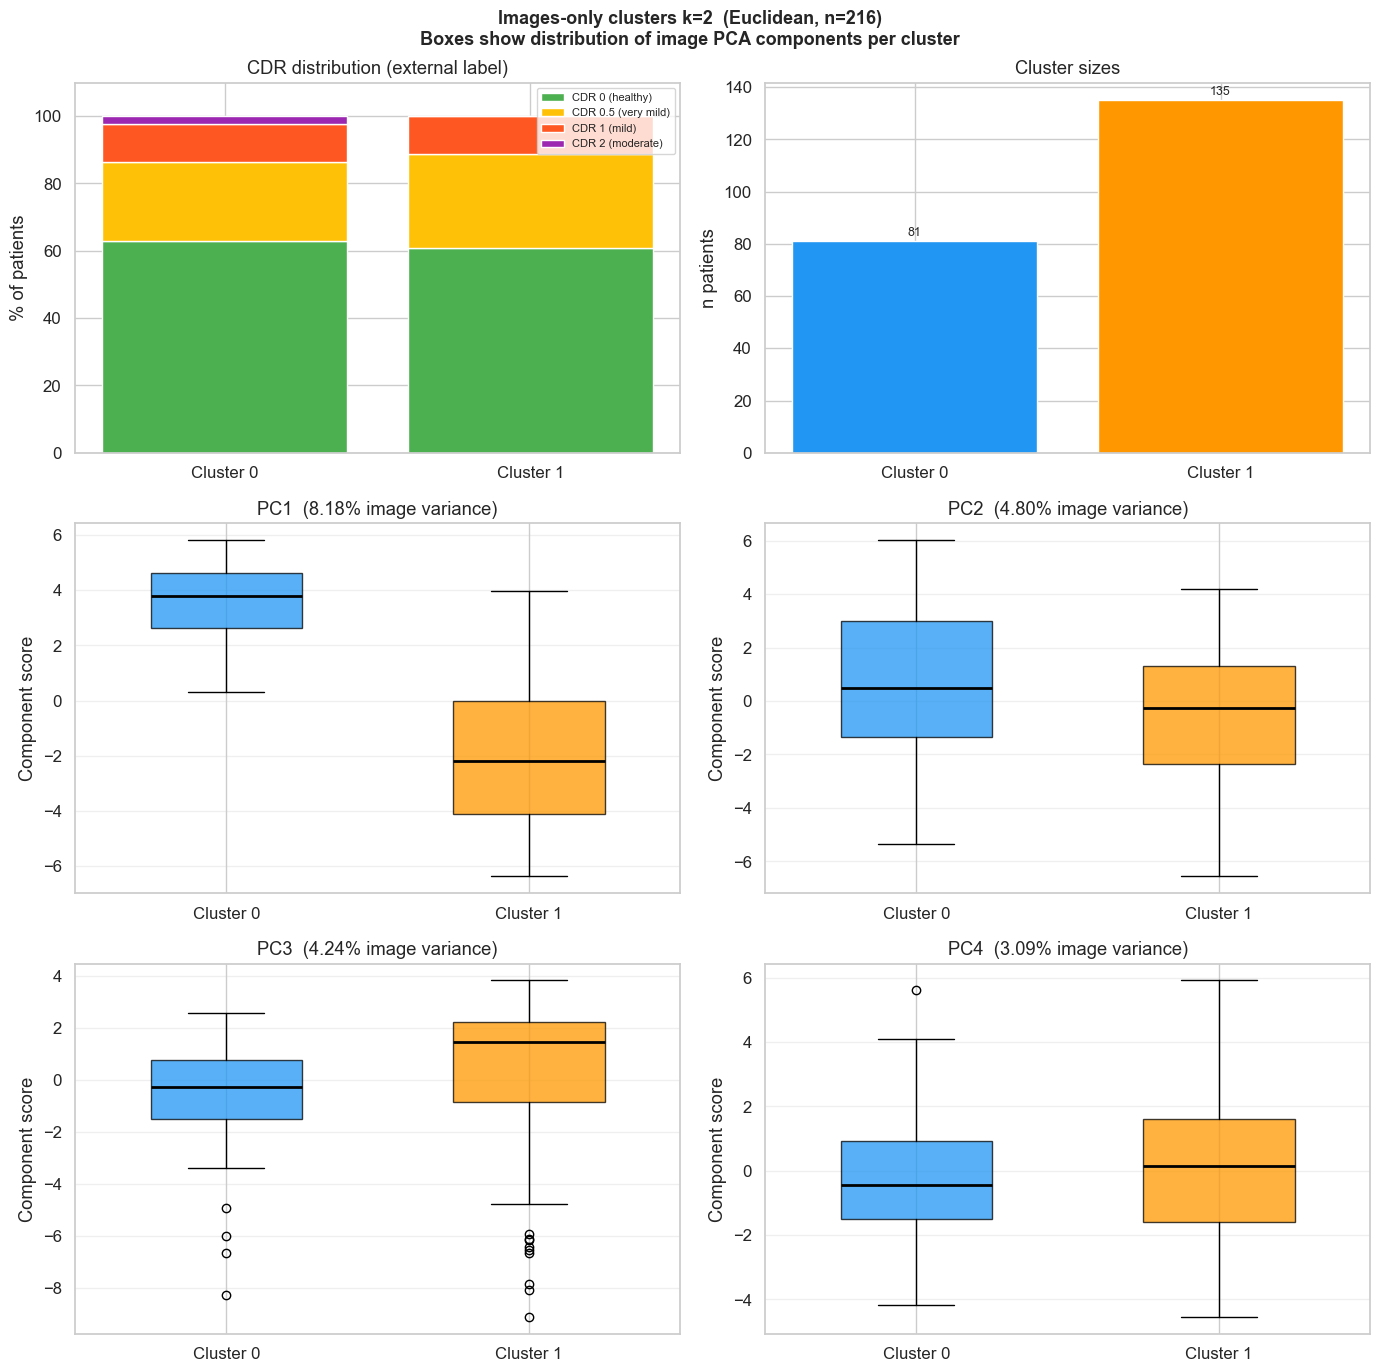

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\img_only_profile_k2.png


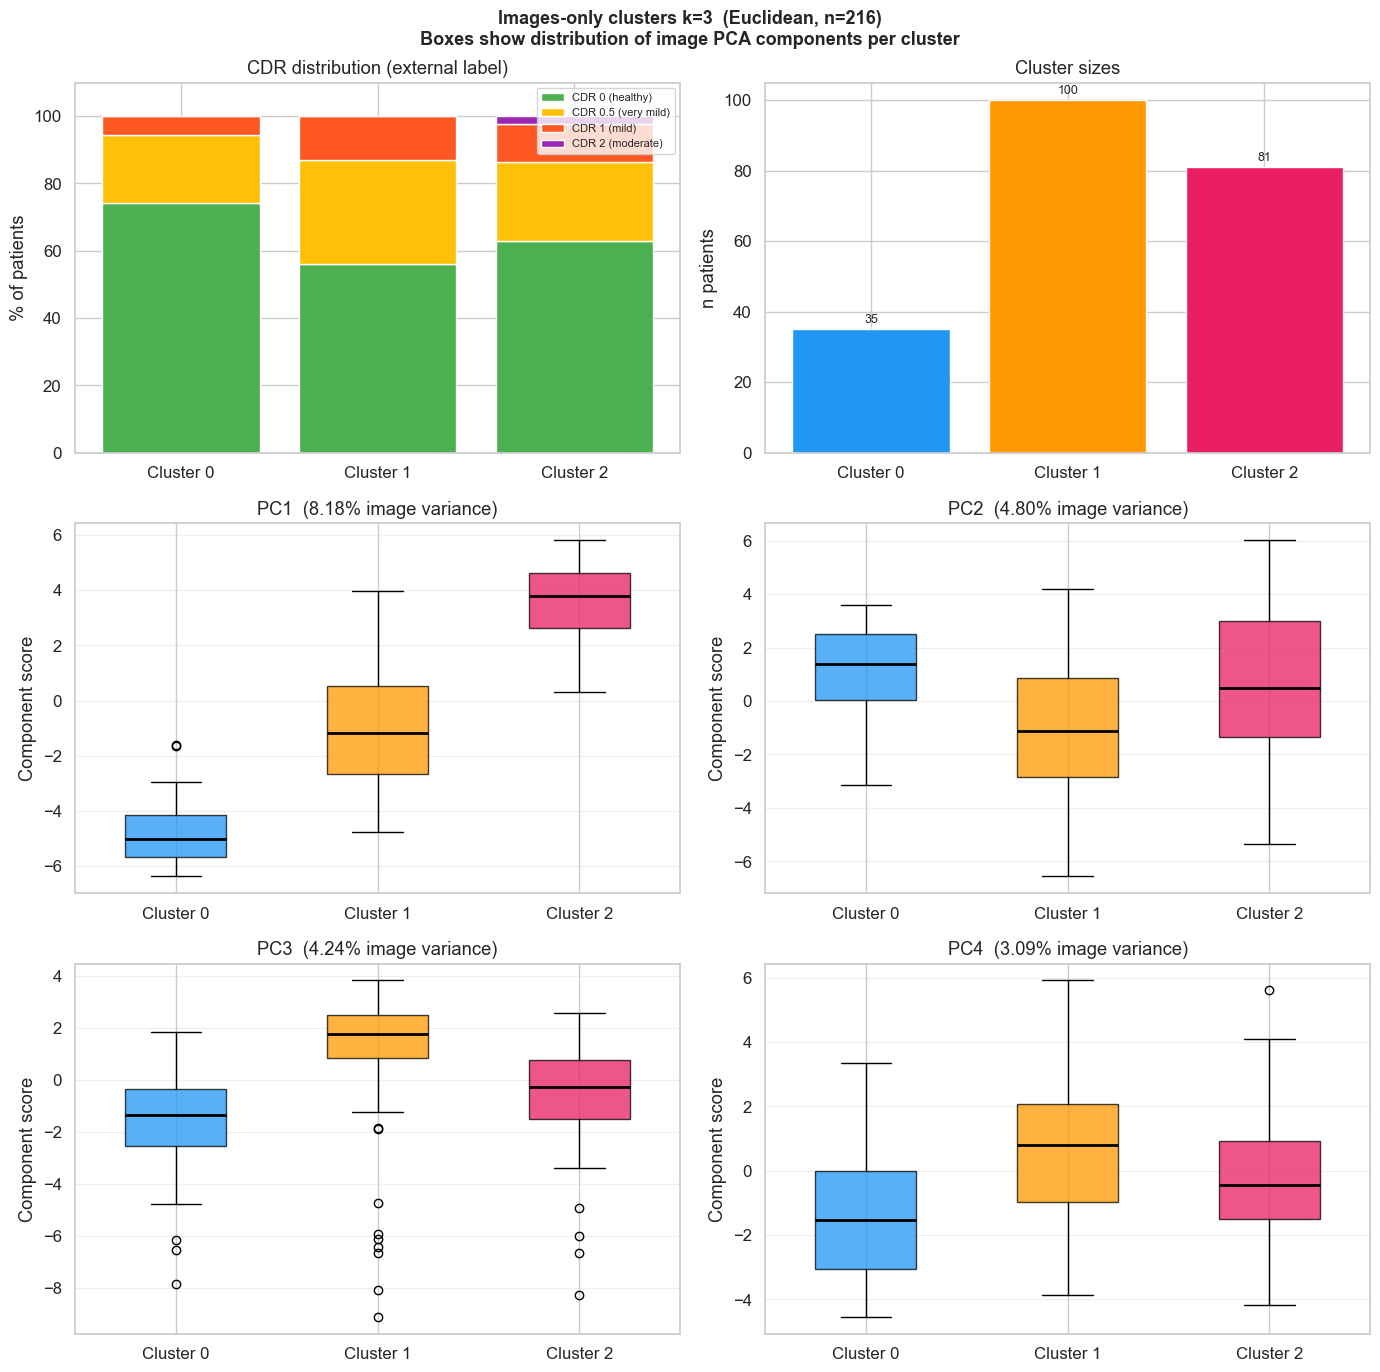

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\img_only_profile_k3.png


In [31]:
# ── Visualisations (images only) — PC1-PC5 boxplots ─────────────────────────
for k in [2, 3]:
    labels      = cluster_labels_img[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'Images-only clusters k={k}  (Euclidean, n=216)\n'
                 'Boxes show distribution of image PCA components per cluster',
                 fontsize=13, fontweight='bold')

    # CDR stacked (external label)
    ax = axes[0, 0]
    plot_cdr_stacked(ax, df_profile, cluster_ids)
    ax.set_title('CDR distribution (external label)')

    # Cluster sizes
    ax = axes[0, 1]
    plot_cluster_sizes(ax, df_profile, cluster_ids)

    # PC1 – PC4 as boxplots
    pc_axes = [axes[1, 0], axes[1, 1], axes[2, 0], axes[2, 1]]
    for i, ax in enumerate(pc_axes):
        data  = [X_img_top5[labels == c, i] for c in cluster_ids]
        bp    = ax.boxplot(data, positions=cluster_ids, widths=0.5, patch_artist=True,
                           medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], cluster_ids):
            patch.set_facecolor(CLUSTER_COLORS[c])
            patch.set_alpha(0.75)
        ax.set_xticks(cluster_ids)
        ax.set_xticklabels([f'Cluster {c}' for c in cluster_ids])
        ax.set_title(f'PC{i+1}  ({var5[i]:.2f}% image variance)')
        ax.set_ylabel('Component score')
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out = os.path.join(NB_PADDED, f'img_only_profile_k{k}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

PC1 explains 8.2%,  PC2 explains 4.8%


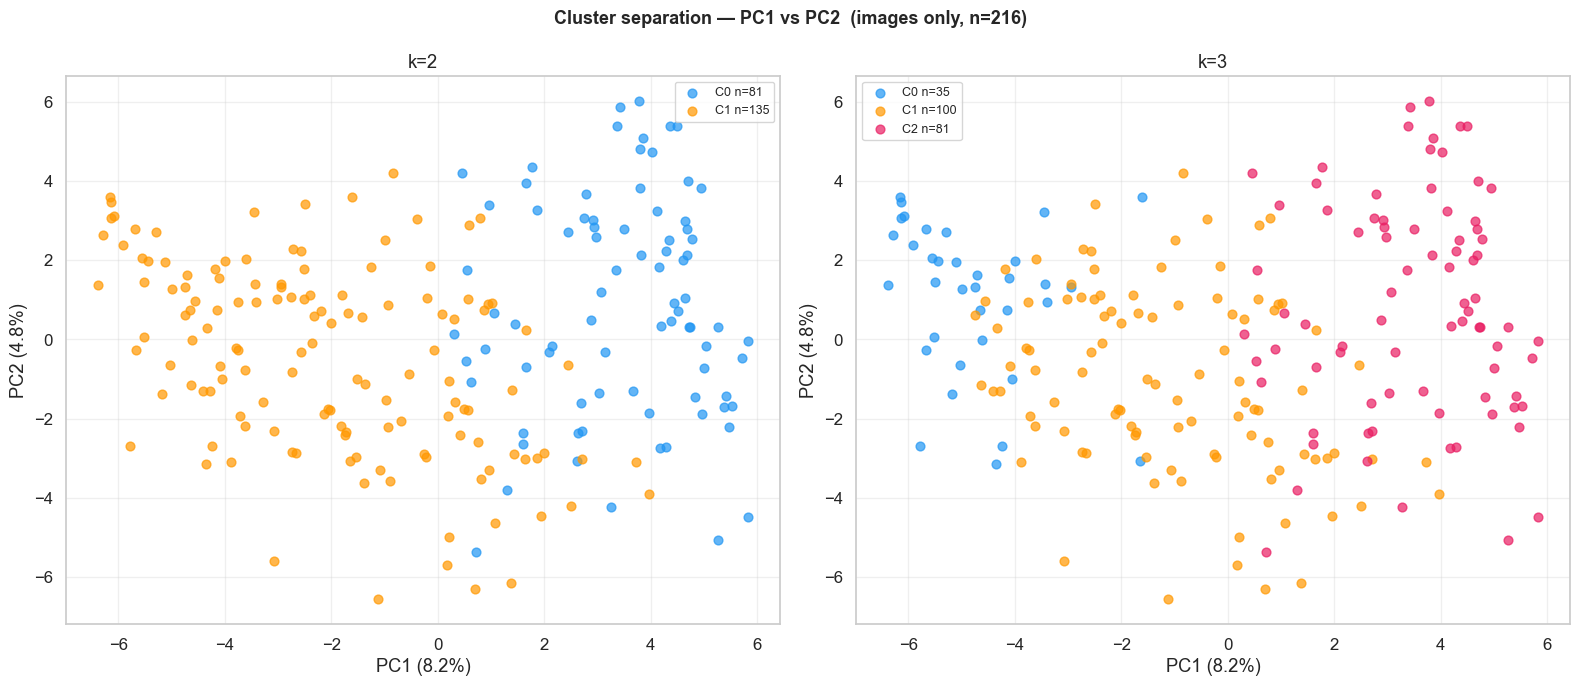

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\img_only_pca_scatter.png


In [32]:
# ── PCA scatter — images only ────────────────────────────────────────────────
pca_img = PCA(n_components=2, random_state=42)
X_img_2d = pca_img.fit_transform(X_img)
var1_i = pca_img.explained_variance_ratio_[0] * 100
var2_i = pca_img.explained_variance_ratio_[1] * 100
print(f'PC1 explains {var1_i:.1f}%,  PC2 explains {var2_i:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Cluster separation — PC1 vs PC2  (images only, n=216)',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, [2, 3]):
    labels      = cluster_labels_img[k]
    cluster_ids = sorted(set(labels))
    for c in cluster_ids:
        mask = labels == c
        ax.scatter(X_img_2d[mask, 0], X_img_2d[mask, 1],
                   color=CLUSTER_COLORS[c], alpha=0.7, s=40, label=f'C{c} n={mask.sum()}')
    ax.set_xlabel(f'PC1 ({var1_i:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2_i:.1f}%)')
    ax.set_title(f'k={k}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(NB_PADDED, 'img_only_pca_scatter.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## Best Image Combination + Clinical — cor + gfc_sag + clinical

**Choice rationale:**
- `cor` (coronal) and `gfc_sag` (sagittal) give two anatomically distinct views of the brain — different planes, no slice overlap
- Both are globally registered (Talairach space), so anatomical locations are comparable across patients
- Avoids the methodological concerns of: `sbj_sag` (unregistered), `masked_tra` (same slice as `gfc_tra` with 45% zeros), and `gfc_tra` (coronal-ish, redundant if `masked_tra` included)

RelMS distance: p1=[110, 110, 5] + p3=3 (same clinical encoding as main experiment)

k=2 is statistically optimal. k=3 shown for clinical comparison.

In [14]:
# ── Feature matrix: cor + gfc_sag + clinical ─────────────────────────────────
QUANT_CLIN   = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF']
MULTCLS_CLIN = ['MF', 'Educ', 'SES']

X_best = np.concatenate([
    pca_blocks['cor'],                                         # 110
    pca_blocks['gfc_sag'],                                     # 110
    df_c[QUANT_CLIN].to_numpy(dtype=np.float64),               # 5   → p1
    df_c[MULTCLS_CLIN].to_numpy(dtype=np.float64),             # 3   → p3
], axis=1)   # shape (216, 228)

print('Computing RelMS distance for cor+gfc_sag+clinical ...')
D_best = related_metric_scaling_dist_matrix_faster(
    X        = pd.DataFrame(X_best),
    p1       = [110, 110, 5],
    p2       = 0,
    p3       = 3,
    d1       = 'euclidean',
    d2       = 'sokal',
    d3       = 'hamming',
    weights  = None,
)
print(f'X_best shape: {X_best.shape}')
print(f'D_best range: [{D_best.min():.4f}, {D_best.max():.4f}]')

Computing RelMS distance for cor+gfc_sag+clinical ...
X_best shape: (216, 228)
D_best range: [0.0000, 8.6659]


C:\Users\aregk\AppData\Local\Programs\Python\Python312\Lib\site-packages\robust_mixed_dist\mixed.py:1002: UserWarning: Gram matrix for block 5 is not PSD (min eig=-1.76e+01). Transformation applied.
  warnings.warn(


In [15]:
# ── Cluster k=2, k=3 ────────────────────────────────────────────────────────
cluster_labels_best = {}

for k in [2, 3]:
    result = kmedoids.fasterpam(D_best, medoids=k, random_state=42)
    cluster_labels_best[k] = np.array(result.labels, dtype=int)
    sizes = {c: int((cluster_labels_best[k] == c).sum()) for c in sorted(set(cluster_labels_best[k]))}
    sil   = silhouette_score(D_best, cluster_labels_best[k], metric='precomputed')
    ari   = adjusted_rand_score(cdr_int, cluster_labels_best[k])
    # compare with all-5-images+clin
    ari_vs_full = adjusted_rand_score(cluster_labels[k], cluster_labels_best[k])
    print(f'k={k}  sil={sil:.4f}  ARI vs CDR={ari:.4f}  ARI vs 5img+clin={ari_vs_full:.4f}  sizes={sizes}')

k=2  sil=0.0269  ARI vs CDR=0.0320  ARI vs 5img+clin=0.6721  sizes={np.int64(0): 149, np.int64(1): 67}
k=3  sil=0.0112  ARI vs CDR=0.0161  ARI vs 5img+clin=0.5045  sizes={np.int64(0): 76, np.int64(1): 58, np.int64(2): 82}


In [16]:
# ── Profiling tables (best combo) ────────────────────────────────────────────
for k in [2, 3]:
    labels      = cluster_labels_best[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    print(f'\n{"="*70}')
    print(f'  BEST COMBO PROFILING — k={k}  (cor+gfc_sag+clinical, n=216)')
    print(f'{"="*70}')
    print('\nCluster sizes:')
    for c, n in df_profile['cluster'].value_counts().sort_index().items():
        print(f'  Cluster {c}: n={n}')

    print('\nQuantitative features (mean ± std):')
    header = 'Feature      ' + '  '.join(f'  Cluster {c}   ' for c in cluster_ids)
    print(header)
    print('-' * len(header))
    for feat in QUANT_DISPLAY:
        parts = [f'{df_profile.loc[df_profile["cluster"]==c, feat].mean():6.2f} '
                 f'± {df_profile.loc[df_profile["cluster"]==c, feat].std():5.2f}'
                 for c in cluster_ids]
        print(f'{feat:<12} ' + '  '.join(parts))

    print('\nCDR distribution (% per cluster):')
    pct = pd.crosstab(df_profile['cluster'], df_profile['CDR'], normalize='index').mul(100).round(1)
    print(pct.to_string())

    print('\nM/F (% female):')
    for c in cluster_ids:
        sub = df_profile.loc[df_profile['cluster']==c, 'M/F']
        print(f'  Cluster {c}: {(sub=="F").mean()*100:.1f}% female')


  BEST COMBO PROFILING — k=2  (cor+gfc_sag+clinical, n=216)

Cluster sizes:
  Cluster 0: n=149
  Cluster 1: n=67

Quantitative features (mean ± std):
Feature        Cluster 0       Cluster 1   
-------------------------------------------
Age           72.23 ± 11.70   72.93 ± 13.64
MMSE          27.28 ±  3.53   27.42 ±  3.24
eTIV         1379.26 ± 96.11  1635.18 ± 131.76
nWBV           0.76 ±  0.05    0.73 ±  0.05
ASF            1.28 ±  0.09    1.08 ±  0.09
Educ           2.93 ±  1.23    3.90 ±  1.32
SES            2.73 ±  1.03    1.96 ±  1.13

CDR distribution (% per cluster):
CDR       0.0   0.5   1.0  2.0
cluster                       
0        65.1  23.5  10.7  0.7
1        53.7  32.8  11.9  1.5

M/F (% female):
  Cluster 0: 86.6% female
  Cluster 1: 23.9% female

  BEST COMBO PROFILING — k=3  (cor+gfc_sag+clinical, n=216)

Cluster sizes:
  Cluster 0: n=76
  Cluster 1: n=58
  Cluster 2: n=82

Quantitative features (mean ± std):
Feature        Cluster 0       Cluster 1       Cluster

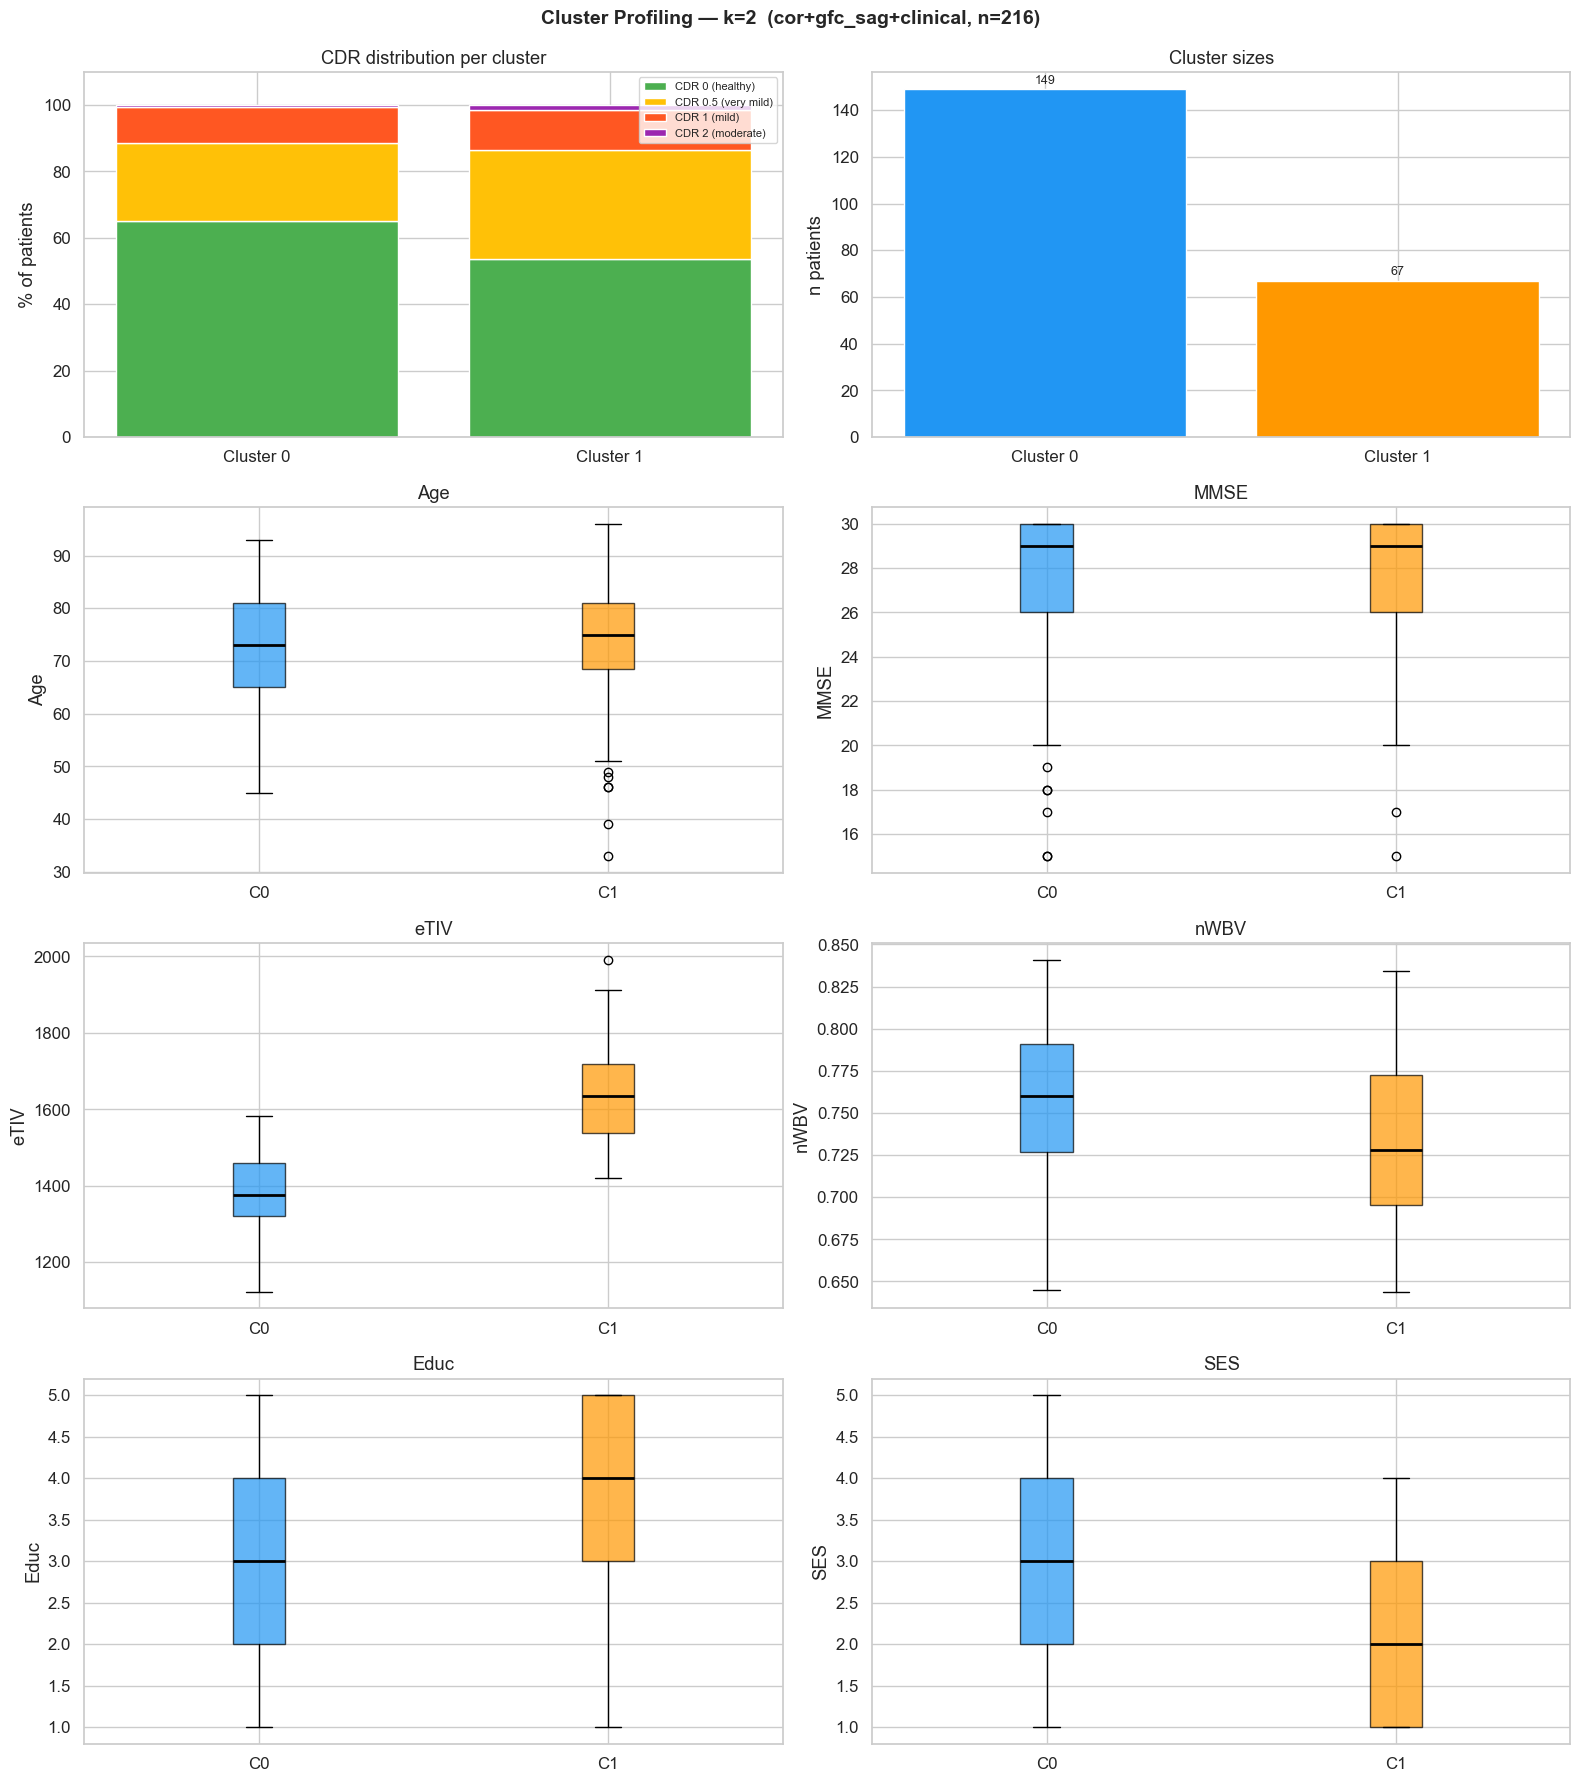

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\best_combo_profile_k2.png


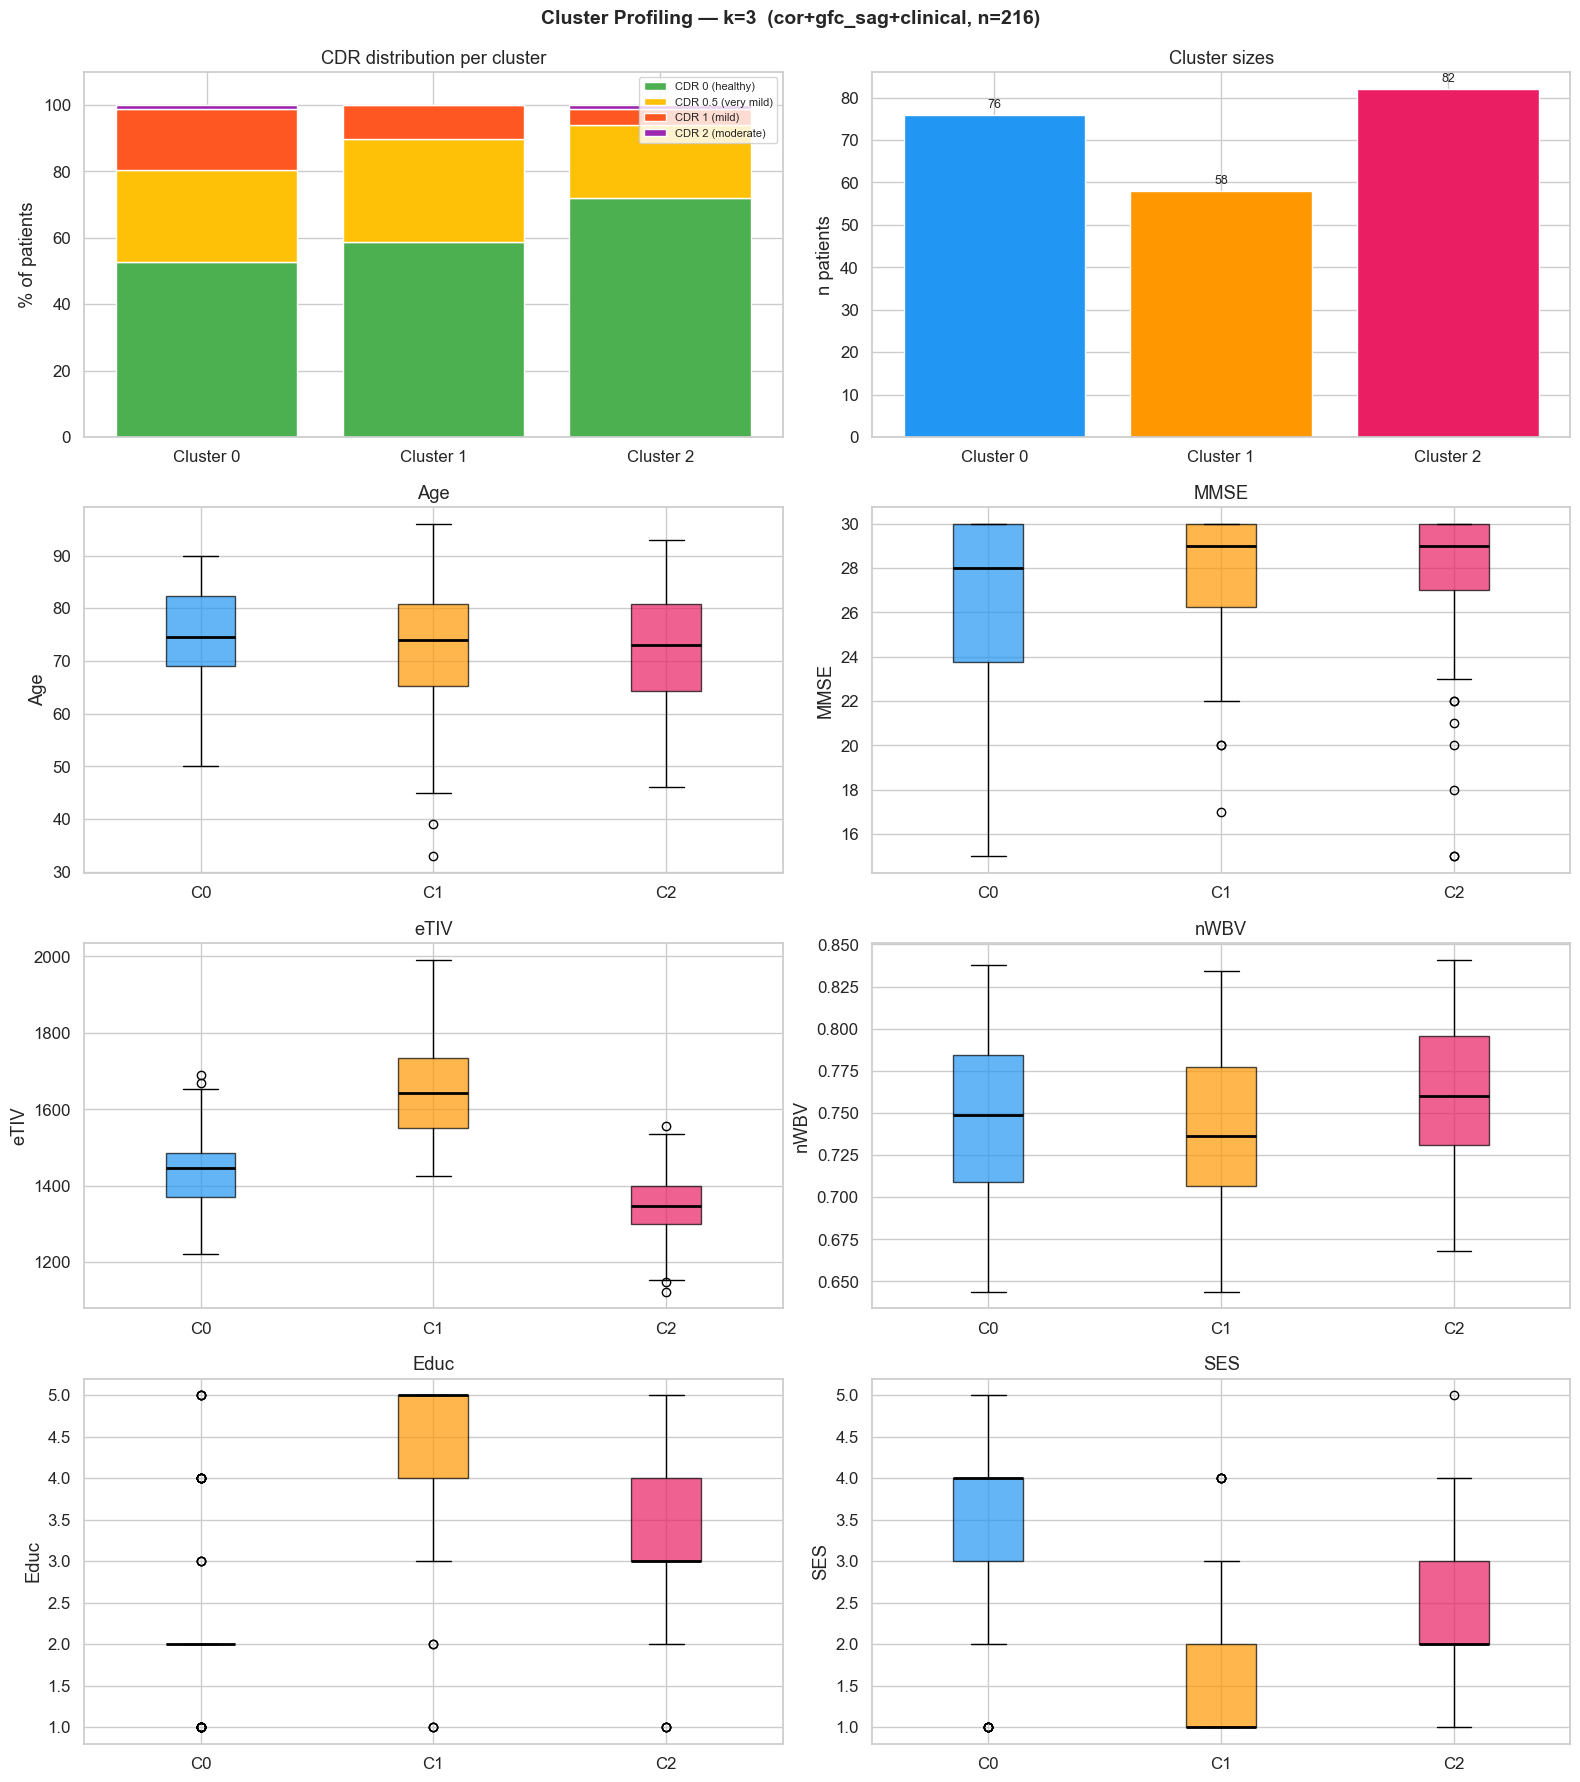

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\best_combo_profile_k3.png


In [17]:
# ── Visualisations (best combo) ──────────────────────────────────────────────
for k in [2, 3]:
    labels      = cluster_labels_best[k]
    df_profile  = df_c.assign(cluster=labels)
    cluster_ids = sorted(df_profile['cluster'].unique())

    fig = plt.figure(figsize=(16, 18))
    fig.suptitle(f'Cluster Profiling — k={k}  (cor+gfc_sag+clinical, n=216)',
                 fontsize=14, fontweight='bold', y=0.99)

    ax1 = fig.add_subplot(4, 2, 1)
    plot_cdr_stacked(ax1, df_profile, cluster_ids)

    ax2 = fig.add_subplot(4, 2, 2)
    plot_cluster_sizes(ax2, df_profile, cluster_ids)

    pairs = [('Age', 'MMSE'), ('eTIV', 'nWBV'), ('Educ', 'SES')]
    for idx, (f1, f2) in enumerate(pairs):
        ax = fig.add_subplot(4, 2, 3 + idx * 2)
        plot_boxplots(ax, df_profile, f1, cluster_ids)
        ax = fig.add_subplot(4, 2, 4 + idx * 2)
        plot_boxplots(ax, df_profile, f2, cluster_ids)

    plt.tight_layout()
    out = os.path.join(NB_PADDED, f'best_combo_profile_k{k}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

PC1 explains 99.2%,  PC2 explains 0.6%


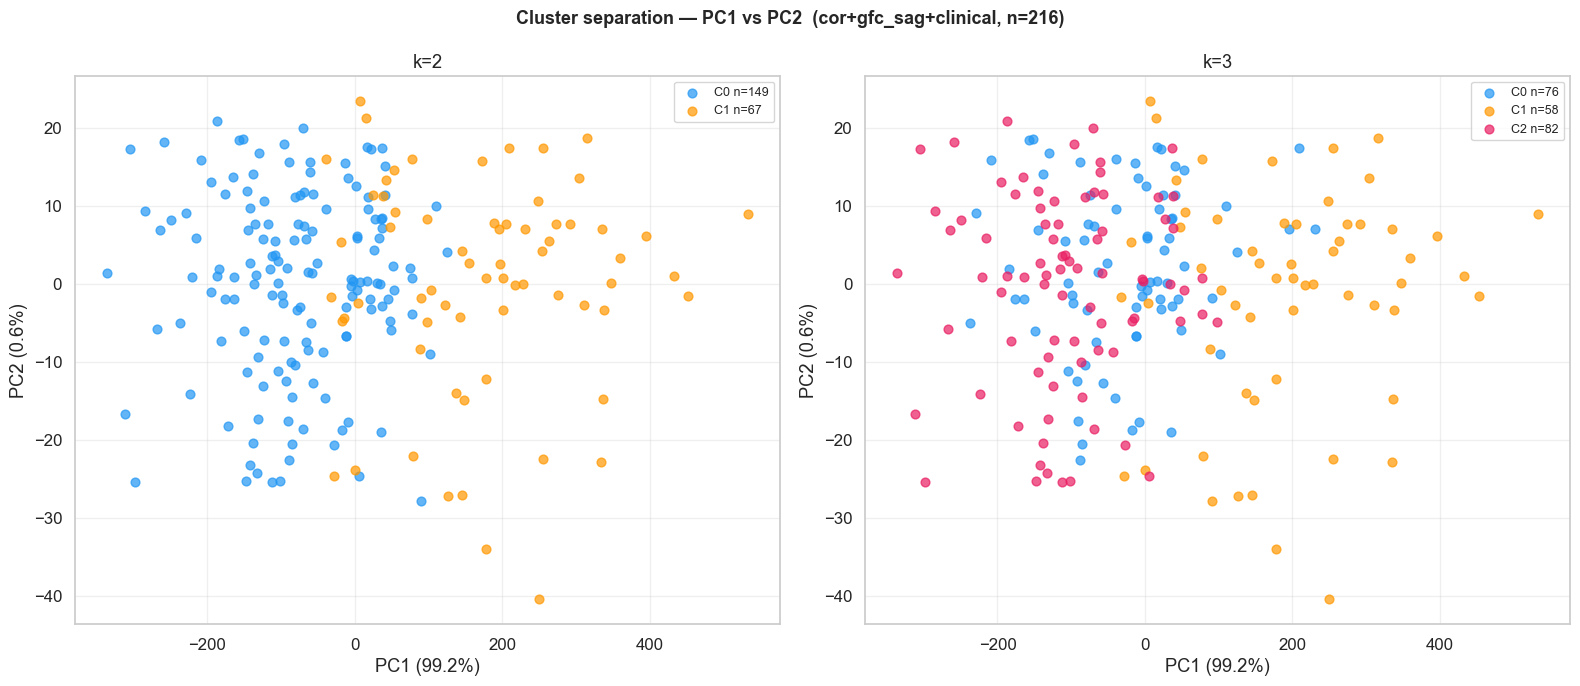

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\best_combo_pca_scatter.png


In [37]:
# ── PCA scatter — best combo ─────────────────────────────────────────────────
pca_best = PCA(n_components=2, random_state=42)
X_best_2d = pca_best.fit_transform(X_best)
var1_b = pca_best.explained_variance_ratio_[0] * 100
var2_b = pca_best.explained_variance_ratio_[1] * 100
print(f'PC1 explains {var1_b:.1f}%,  PC2 explains {var2_b:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Cluster separation — PC1 vs PC2  (cor+gfc_sag+clinical, n=216)',
             fontsize=13, fontweight='bold')

for ax, k in zip(axes, [2, 3]):
    labels      = cluster_labels_best[k]
    cluster_ids = sorted(set(labels))
    for c in cluster_ids:
        mask = labels == c
        ax.scatter(X_best_2d[mask, 0], X_best_2d[mask, 1],
                   color=CLUSTER_COLORS[c], alpha=0.7, s=40, label=f'C{c} n={mask.sum()}')
    ax.set_xlabel(f'PC1 ({var1_b:.1f}%)')
    ax.set_ylabel(f'PC2 ({var2_b:.1f}%)')
    ax.set_title(f'k={k}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(NB_PADDED, 'best_combo_pca_scatter.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

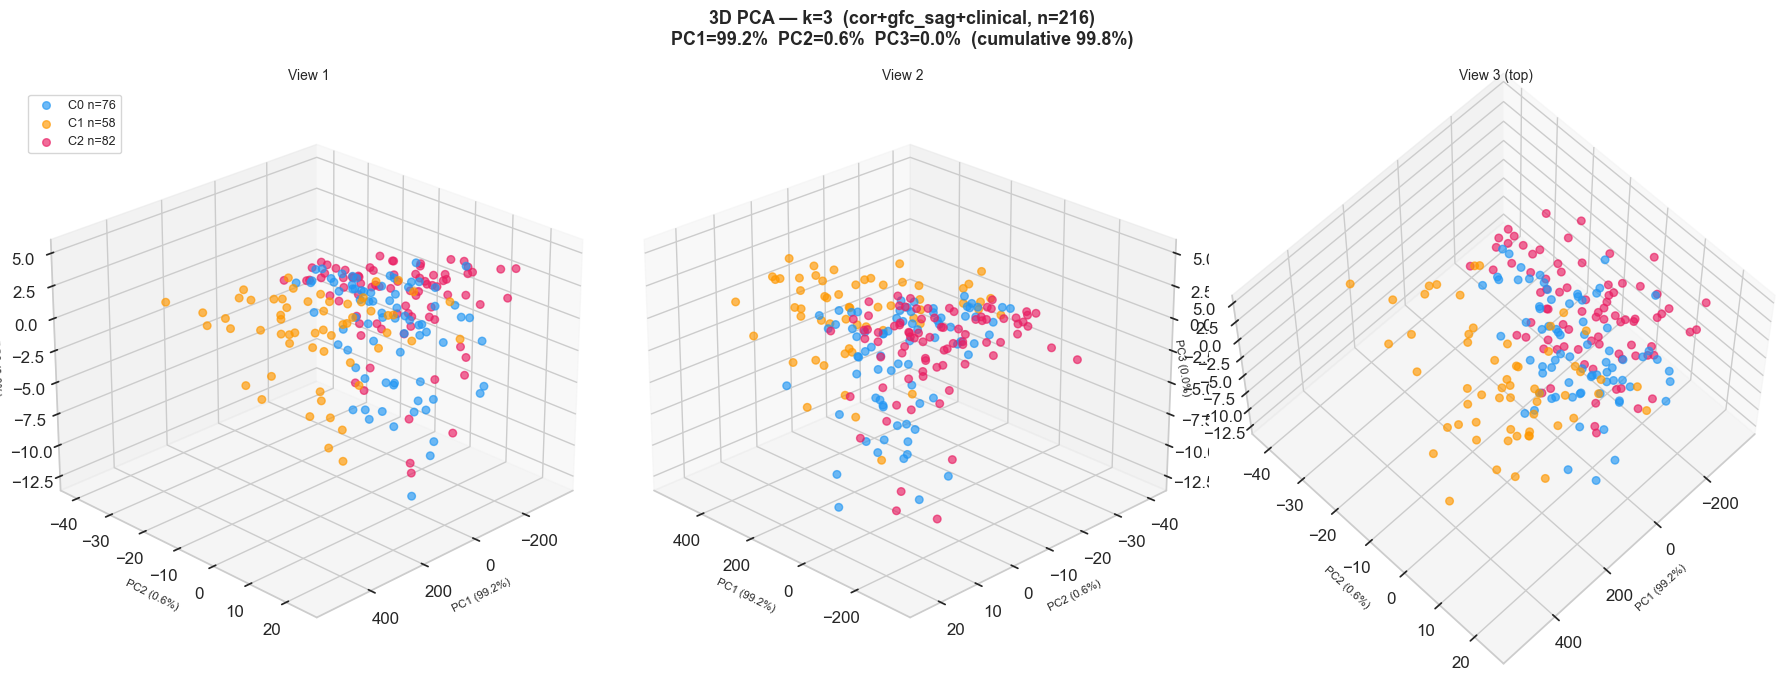

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\pca_3d_best_combo_k3.png


In [38]:
# ── 3D PCA scatter — cor+gfc_sag+clinical, k=3 ──────────────────────────────
pca_3d_best = PCA(n_components=3, random_state=42)
X_3d_best   = pca_3d_best.fit_transform(X_best)
v3b = pca_3d_best.explained_variance_ratio_ * 100

k       = 3
labels  = cluster_labels_best[k]
c_ids   = sorted(set(labels))

fig = plt.figure(figsize=(18, 7))
fig.suptitle(f'3D PCA — k=3  (cor+gfc_sag+clinical, n=216)\n'
             f'PC1={v3b[0]:.1f}%  PC2={v3b[1]:.1f}%  PC3={v3b[2]:.1f}%  '
             f'(cumulative {sum(v3b):.1f}%)',
             fontsize=13, fontweight='bold')

for col, (elev, azim, title) in enumerate([(25, 45, 'View 1'),
                                            (25, 135, 'View 2'),
                                            (60, 45, 'View 3 (top)')]):
    ax = fig.add_subplot(1, 3, col+1, projection='3d')
    for c in c_ids:
        mask = labels == c
        ax.scatter(X_3d_best[mask, 0], X_3d_best[mask, 1], X_3d_best[mask, 2],
                   color=CLUSTER_COLORS[c], alpha=0.65, s=30,
                   label=f'C{c} n={mask.sum()}')
    ax.set_xlabel(f'PC1 ({v3b[0]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_ylabel(f'PC2 ({v3b[1]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_zlabel(f'PC3 ({v3b[2]:.1f}%)', fontsize=8, labelpad=4)
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)
    if col == 0:
        ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
out = os.path.join(NB_PADDED, 'pca_3d_best_combo_k3.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

---
## Feature Separation Between Clusters (Effect Sizes)

The tables above show each feature's mean per cluster. To quantify **how different**
a feature actually is between clusters — instead of eyeballing it — we use effect sizes.
This is the main question: *which features drive the clustering, and by how much?*

| Measure | Feature type | Range | Reading |
|---|---|---|---|
| **$\eta^2$** (eta-squared) | continuous / ordinal | 0–1 | fraction of the feature's variance explained by cluster membership |
| **Cramér's V** | nominal (M/F) | 0–1 | strength of association between the feature and cluster membership |

$\eta^2$ is derived from the Kruskal–Wallis $H$ statistic:
$\;\eta^2 = (H - k + 1) / (n - k)$.
Rough guide: $0.01$ = small, $0.06$ = medium, $0.14$ = large effect.

CDR is included as an **external label** (never used in any clustering) so we can see
whether the clusters happen to align with disease severity.

In [39]:
# ── Effect-size helpers ──────────────────────────────────────────────────────
from scipy.stats import kruskal, chi2_contingency

def eta_squared(values, labels):
    """Epsilon/eta-squared from Kruskal-Wallis. Continuous or ordinal feature."""
    values = np.asarray(values, dtype=float)
    labels = np.asarray(labels)
    groups = [values[labels == c] for c in np.unique(labels)]
    if any(len(g) == 0 for g in groups):
        return np.nan
    H, _ = kruskal(*groups)
    n = len(values)
    k = len(groups)
    return max(0.0, (H - k + 1) / (n - k))

def cramers_v(cat_values, labels):
    """Cramér's V between a categorical feature and cluster labels."""
    ct = pd.crosstab(pd.Series(cat_values), pd.Series(labels))
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, c = ct.shape
    denom = n * (min(r, c) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

CONT_FEATS = ['Age', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'Educ', 'SES']  # eta^2
NOM_FEATS  = ['MF']                                                  # Cramer's V

print('Effect-size helpers ready.')

Effect-size helpers ready.


In [40]:
# ── Feature separation per experiment (ranked by effect size) ────────────────
# Each experiment's clusters, profiled by how strongly every clinical feature
# separates them. CDR is external (not used in clustering).

experiments = {
    '5 images + clinical': cluster_labels,
    'clinical only':       cluster_labels_clin,
    'cor+gfc_sag+clinical': cluster_labels_best,
    'images only':         cluster_labels_img,
}

for exp_name, lab_dict in experiments.items():
    for k in [2, 3]:
        labels = lab_dict[k]
        rows = []
        for feat in CONT_FEATS:
            rows.append((feat, 'eta2', eta_squared(df_c[feat].values, labels)))
        for feat in NOM_FEATS:
            rows.append((feat, "Cramer V", cramers_v(df_c[feat].values, labels)))
        # external: CDR alignment
        cdr_assoc = cramers_v(df_c['CDR'].values, labels)

        rows.sort(key=lambda r: (np.nan_to_num(r[2], nan=-1)), reverse=True)

        print(f'{"="*58}')
        print(f'  {exp_name}  —  k={k}')
        print(f'{"="*58}')
        print(f'  {"Feature":<8}{"measure":<10}{"effect":>8}   strength')
        print('  ' + '-' * 44)
        for feat, meas, val in rows:
            if np.isnan(val):
                bar, tag = '', 'n/a'
            else:
                lvl = 'large' if val >= 0.14 else 'medium' if val >= 0.06 else 'small' if val >= 0.01 else 'negligible'
                bar = '#' * int(round(val * 30))
                tag = f'{lvl:<10} {bar}'
            print(f'  {feat:<8}{meas:<10}{val:>8.3f}   {tag}')
        print(f'  {"-"*44}')
        print(f'  CDR (external)  Cramer V {cdr_assoc:>7.3f}   '
              f'{"clusters align with disease" if cdr_assoc >= 0.14 else "weak/no CDR alignment"}')
        print()

  5 images + clinical  —  k=2
  Feature measure     effect   strength
  --------------------------------------------
  MF      Cramer V     0.642   large      ###################
  eTIV    eta2         0.558   large      #################
  ASF     eta2         0.558   large      #################
  Educ    eta2         0.091   medium     ###
  SES     eta2         0.068   medium     ##
  nWBV    eta2         0.022   small      #
  Age     eta2         0.000   negligible 
  MMSE    eta2         0.000   negligible 
  --------------------------------------------
  CDR (external)  Cramer V   0.132   weak/no CDR alignment

  5 images + clinical  —  k=3
  Feature measure     effect   strength
  --------------------------------------------
  MF      Cramer V     0.560   large      #################
  eTIV    eta2         0.543   large      ################
  ASF     eta2         0.542   large      ################
  Educ    eta2         0.287   large      #########
  SES     eta2         0.2

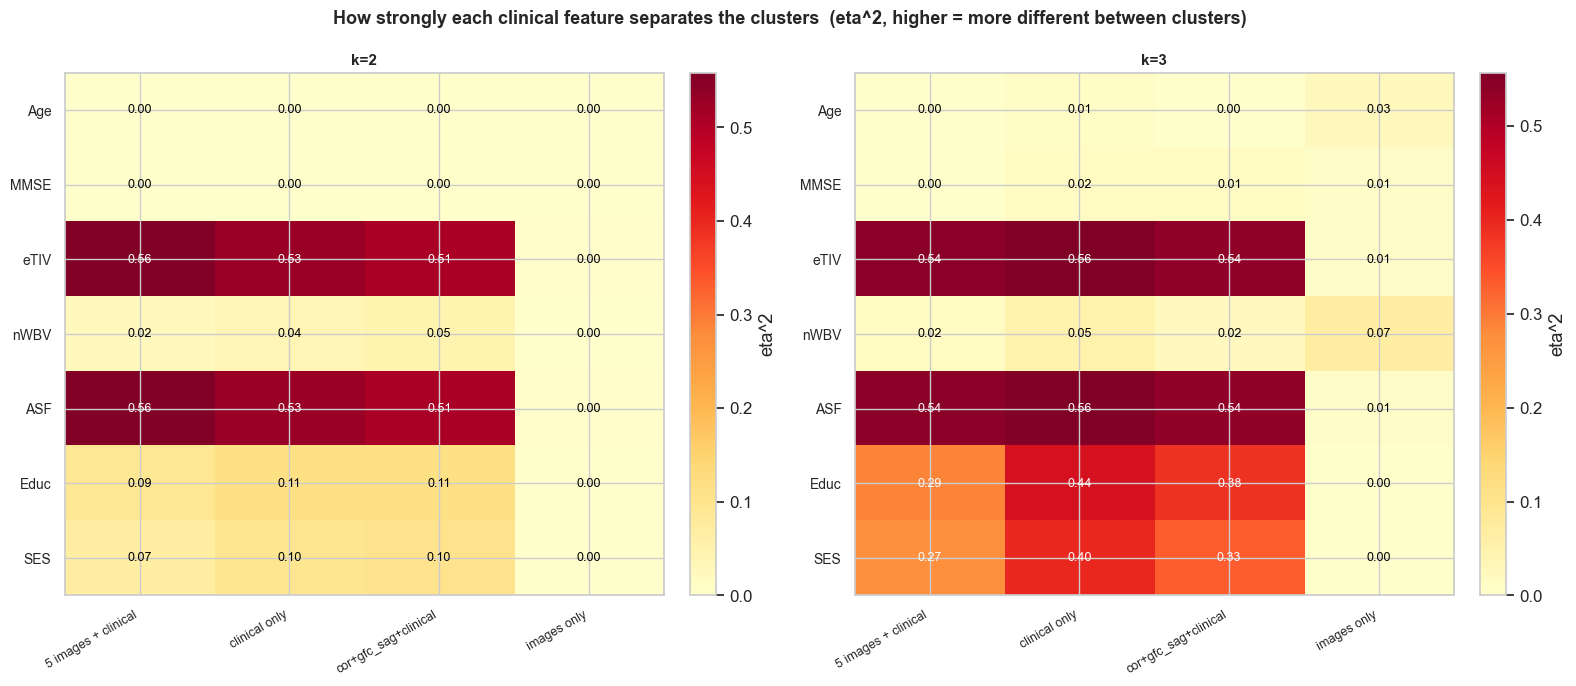

Saved: C:\Users\aregk\OneDrive\Desktop\Thesis_downoading_the_data\notebooks\new_results_with_padding\feature_separation_eta2.png


In [41]:
# ── Money plot: eta^2 of each clinical feature across all experiments ────────
# Rows = features, Columns = experiments. Higher = feature separates clusters more.
# For 'images only' these are EXTERNAL (features were not used) — shows whether
# image-derived clusters accidentally recover clinical structure.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('How strongly each clinical feature separates the clusters  '
             '(eta^2, higher = more different between clusters)',
             fontsize=13, fontweight='bold')

exp_order = ['5 images + clinical', 'clinical only', 'cor+gfc_sag+clinical', 'images only']

for ax, k in zip(axes, [2, 3]):
    mat = np.zeros((len(CONT_FEATS), len(exp_order)))
    for j, exp_name in enumerate(exp_order):
        labels = experiments[exp_name][k]
        for i, feat in enumerate(CONT_FEATS):
            mat[i, j] = eta_squared(df_c[feat].values, labels)

    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=max(0.3, mat.max()), aspect='auto')
    ax.set_xticks(range(len(exp_order)))
    ax.set_xticklabels(exp_order, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(CONT_FEATS)))
    ax.set_yticklabels(CONT_FEATS, fontsize=10)
    ax.set_title(f'k={k}', fontsize=11, fontweight='bold')
    for i in range(len(CONT_FEATS)):
        for j in range(len(exp_order)):
            v = mat[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='black' if v < 0.18 else 'white', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='eta^2')

plt.tight_layout()
out = os.path.join(NB_PADDED, 'feature_separation_eta2.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [42]:
# ── Images only: eta^2 of the top-5 image PCA components ────────────────────
# Which principal component drives the image-only clustering?
print('Images-only clusters: effect size (eta^2) of each top-5 PCA component')
print()
for k in [2, 3]:
    labels = cluster_labels_img[k]
    print(f'  k={k}:')
    for i in range(5):
        e = eta_squared(X_img_top5[:, i], labels)
        lvl = 'large' if e >= 0.14 else 'medium' if e >= 0.06 else 'small' if e >= 0.01 else 'negligible'
        bar = '#' * int(round(e * 30))
        print(f'    PC{i+1} ({var5[i]:5.2f}% var)  eta2={e:6.3f}  {lvl:<10} {bar}')
    print()

Images-only clusters: effect size (eta^2) of each top-5 PCA component

  k=2:
    PC1 ( 8.18% var)  eta2= 0.619  large      ###################
    PC2 ( 4.80% var)  eta2= 0.045  small      #
    PC3 ( 4.24% var)  eta2= 0.089  medium     ###
    PC4 ( 3.09% var)  eta2= 0.004  negligible 
    PC5 ( 2.82% var)  eta2= 0.008  negligible 

  k=3:
    PC1 ( 8.18% var)  eta2= 0.741  large      ######################
    PC2 ( 4.80% var)  eta2= 0.129  medium     ####
    PC3 ( 4.24% var)  eta2= 0.324  large      ##########
    PC4 ( 3.09% var)  eta2= 0.085  medium     ###
    PC5 ( 2.82% var)  eta2= 0.047  small      #

